# Flight Analytics Dashboard

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from math import sin, cos, radians, sqrt

### Helper functions

In [2]:
# Function to load and merge data from CSV files
def load_data(CONTROLLER_TYPE, TRAJECTORY_COUNT) -> pd.DataFrame:
    # CONTROLLER_TYPE -> 1-5: PID, Mel, INDI, Bres, Lee
    # TRAJECTORY_COUNT -> 0-3: hover, line, sine wave, figure eight

    ctrl_names = ['PID', 'Mel', 'INDI', 'Bres', 'Lee']
    ctrl_folder_name = ctrl_names[CONTROLLER_TYPE - 1]

    # load data from CSV files
    df_cf_hover = pd.read_csv(f'logs/{ctrl_folder_name}/cf_log_{TRAJECTORY_COUNT}.csv')
    df_opti_hover = pd.read_csv(f'logs/{ctrl_folder_name}/opti_log_{TRAJECTORY_COUNT}.csv')
    df_opti_hover = df_opti_hover.rename(columns={'x': 'x_act', 'y': 'y_act', 'z': 'z_act'})
    
    # merge dataframes on timestamp
    df = pd.merge_asof(df_cf_hover, df_opti_hover, on='timestamp', direction='nearest', tolerance=0.05)
    
    # if no matching Optitrack -> drop the whole row
    df = df.dropna(subset=['x_act', 'y_act', 'z_act'])
    return df

In [3]:
# for example
load_data(1, 2).columns

Index(['timestamp', 'x', 'y', 'z', 'target_x', 'target_y', 'target_z', 'roll',
       'pitch', 'yaw', 'controller', 'x_act', 'y_act', 'z_act'],
      dtype='object')

### Metrics Overview

#### 3D Trajectory Comparison: Referance vs. Actual
Plot compares referance trajectory (gray dashed lines) with actual flight trajectory (blue lines) taken from Optitrack system.

**What to look for**
* -> Deviations between the referance and actual trajectory (by gaps between two lines).
* -> Check if yaw orientation (red arrows) aligns with the trajectory direction.
* -> Identify any abrupt changes in trajectory that may indicate instability.

In [4]:
def enhanced_visualise_planned_path_3D(df):
    # in df must be columns:
        # 'target_x', 'target_y', 'target_z'  -> planned path
        # 'x_act', 'y_act', 'z_act'           -> actual path
        # 'yaw'                               -> yaw angle in degrees
        
    plt.figure(figsize=(10, 8))
    ax = plt.axes(projection="3d")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_zlabel("Z [m]")

    # plot planned vs actual path
    ax.plot(df['target_x'], df['target_y'], df['target_z'], 
            color='gray', linestyle='--', linewidth=1.5, label='Reference (Plan)')
    ax.plot(df['x_act'], df['y_act'], df['z_act'], 
            color='blue', linewidth=2, label='Actual (Optitrack)')
    ax.scatter(df['x_act'], df['y_act'], df['z_act'], 
               color='cyan', s=5, alpha=0.3)

    # plot yaw
    skip_step = 2
    xs = df['x_act'].values
    ys = df['y_act'].values
    zs = df['z_act'].values
    yaws = df['yaw'].values
    for i in range(0, len(xs), skip_step):
        u = 0.1* cos(radians(yaws[i]))
        v =  0.1* sin(radians(yaws[i]))
        ax.quiver(xs[i], ys[i], zs[i], u, v, 0, color='crimson', length=0.1, normalize=True) # z=0 in pointing direction to have no pitch/roll

    ax.set_box_aspect([1,1,1]) # not to distort the 3D plot
    ax.legend()
    plt.show()

#### 2D Dashboard Analytics

A small dashboard showing key metrics of the flight performance as for tracking accuracy and time-response characteristics.

**Metrics to monitor**
1. XY trajectory error (0,0) -> to check if CF "cuts corners" or drifts
2. Tracking (3D Euclidean) error (0,1) -> peaks in graph shows moments when controller struggles
3. X-axis and Y-axis response -> phase lag - ctrl response delay, overshoot - if 
over-damped or under-damped

In [196]:
def dashboard(df, title):
    # Euclidean dist error
    error = np.sqrt((df['target_x'] - df['x_act'])**2 + 
                    (df['target_y'] - df['y_act'])**2)
    rmse = np.sqrt(np.mean(error**2))

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"{title} (RMSE: {rmse:.3f} m)", fontsize=16)

    # XY TRAJECTORY 
    axs[0, 0].plot(df['target_x'], df['target_y'], 'k--', label='Reference', alpha=0.6)
    axs[0, 0].plot(df['x_act'], df['y_act'], 'b-', label='Actual', linewidth=2)
    axs[0, 0].set_title('XY Trajectory (Top Down)')
    axs[0, 0].set_xlabel('X [m]')
    axs[0, 0].set_ylabel('Y [m]')
    axs[0, 0].legend()
    axs[0, 0].grid(True)
    axs[0, 0].axis('equal')

    # EUCLIDIAN ERROR OVER TIME
    time = df['timestamp'] - df['timestamp'].iloc[0]
    df['err_x'] = df['target_x'] - df['x_act']
    df['err_y'] = df['target_y'] - df['y_act']
    df['err_z'] = df['target_z'] - df['z_act']
    axs[0, 1].plot(time, df['err_x'], label='Error X', color='r')
    axs[0, 1].plot(time, df['err_y'], label='Error Y', color='g')
    axs[0, 1].plot(time, df['err_z'], label='Error Z', color='b')
    axs[0, 1].set_xlabel('Time [s]')
    axs[0, 1].set_ylabel('Tracking Error (m)')
    axs[0, 1].set_title('Tracking Error Over Time')
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # X-AXIS RESPONSE (to see lags)
    axs[1, 0].plot(df['timestamp'], df['target_x'], 'k--', label='Ref X')
    axs[1, 0].plot(df['timestamp'], df['x_act'], 'b-', label='Act X')
    axs[1, 0].set_title('X-Axis Response (Check for Lag)')
    axs[1, 0].set_xlabel('Time [s]')
    axs[1, 0].set_ylabel('Position X [m]')
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    # Y-AXIS RESPONSE
    axs[1, 1].plot(df['timestamp'], df['target_y'], 'k--', label='Ref Y')
    axs[1, 1].plot(df['timestamp'], df['y_act'], 'b-', label='Act Y')
    axs[1, 1].set_title('Y-Axis Response')
    axs[1, 1].set_xlabel('Time [s]')
    axs[1, 1].set_ylabel('Position Y [m]')
    axs[1, 1].legend()
    axs[1, 1].grid(True)
    plt.show()

#### Root Mean Square Error (RMSE)
Using this metrics, we can measure average error between target and actual values. In general RMSE measures deviation of residuals (prediction errors) -> in or case it tells us the **average distance** between CF actual position and target position.

$$ MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 $$

In [5]:
def rmse(df):
    # per axis
    df['err_x'] = df['target_x'] - df['x_act']
    df['err_y'] = df['target_y'] - df['y_act']
    df['err_z'] = df['target_z'] - df['z_act']

    rmse_x = np.sqrt(np.mean(df['err_x'] ** 2))
    rmse_y = np.sqrt(np.mean(df['err_y'] ** 2))
    rmse_z = np.sqrt(np.mean(df['err_z'] ** 2))

    # in 3D
    df['error_3d'] = np.sqrt(df['err_x']**2 + df['err_y']**2 + df['err_z']**2)
    rmse_total = np.sqrt(np.mean(df['error_3d'] ** 2))
    max_error = df['error_3d'].max()

    # print results
    print(f"Total 3D RMSE:      {rmse_total:.4f} m")
    print(f"Max Tracking Error: {max_error:.4f} m")
    print("Breakdown by Axis:")
    print(f"  X-Axis RMSE:      {rmse_x:.4f} m")
    print(f"  Y-Axis RMSE:      {rmse_y:.4f} m")
    print(f"  Z-Axis RMSE:      {rmse_z:.4f} m")

    # plot bar chart
    plt.figure(figsize=(8, 5))
    metrics = ['X-Axis', 'Y-Axis', 'Z-Axis', 'Total 3D']
    values = [rmse_x, rmse_y, rmse_z, rmse_total]
    colors = ['skyblue', 'skyblue', 'skyblue', 'salmon']
    plt.bar(metrics, values, color=colors)
    plt.grid(axis='y')
    plt.ylabel('RMSE (m)')
    plt.title('RMSE by Axis and Total 3D RMSE')
    plt.show()

## PID

##### **Hover Analytics**

First load data from hover test flight and merge CF and Optitrack data based on timestamps.

In [199]:
# hover
pid_hover = load_data(1,0)
pid_hover.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.000553,0.004141,0.003753,0.014077,0,0,0.8,0.122873,-0.601206,-0.122829,1,0.004459,0.003750,0.014095
1,0.103732,0.004415,0.003669,0.015264,0,0,0.8,0.064678,0.474204,-0.305703,1,0.003600,0.003769,0.016592
2,0.204557,0.001289,0.004465,0.035106,0,0,0.8,-0.821847,4.818843,-0.366133,1,-0.001540,0.006182,0.045224
3,0.305097,-0.012382,0.009283,0.095930,0,0,0.8,-0.050370,1.674865,-0.692285,1,-0.016009,0.011832,0.112061
4,0.405630,-0.029703,0.016418,0.183171,0,0,0.8,0.323725,-1.027032,-0.862411,1,-0.033155,0.018841,0.201528


Then first let's visualize the position tracking performance in 3D space.
<br>On graph below, we cannot see desired position because it is constant (0,0,0.8).
For z axes we see that drone started going up, but in xy axes it drifts away from origin.

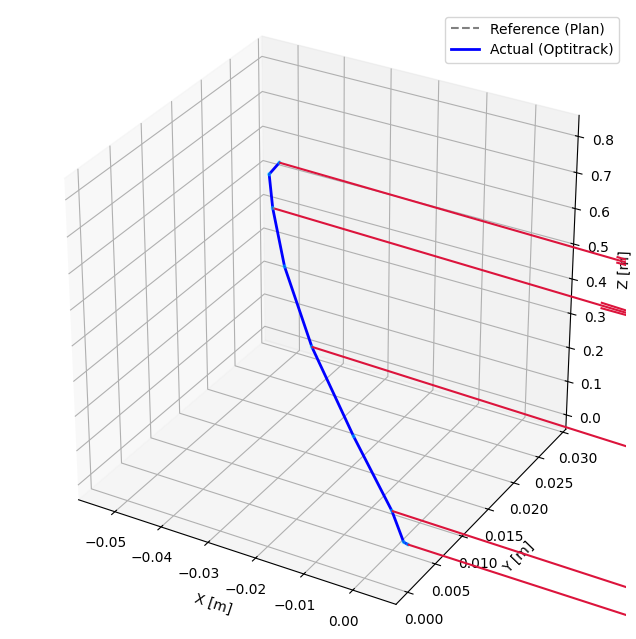

In [200]:
enhanced_visualise_planned_path_3D(pid_hover) # type: ignore

Graph below will give more information about tracking error over time.

<br>**Top left graph** - we see CF deviation of xy from target (0,0) -> controller struggles to keep CF on target.
<br>**Top right graph** - we see 3D Euclidean error over time 
* -> for xy error we see that line is not straight at 0, meaning that CF is drifting away from target.
* -> for z error we see that it decreases over time, meaning that CF is getting closer to target altitude.
<br>

**Bottom left and right graphs** - we see x and y axis response over time.
* -> in x we see that CF overshoots target position and then is moving away from target.
* -> in y CF never reaches target position and is moving away from it.

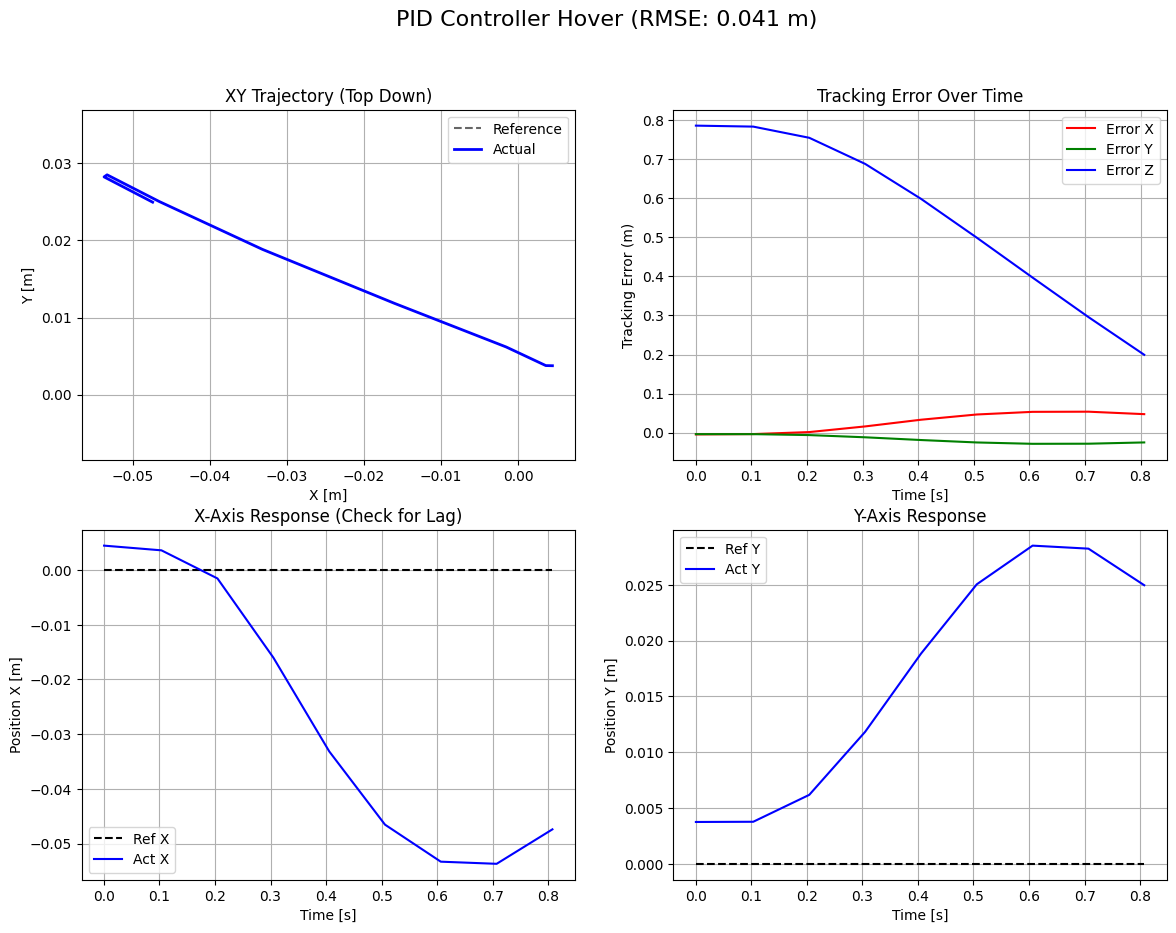

In [203]:
dashboard(pid_hover, "PID Controller Hover")

Next let's calculate RMSE for hover test flight to quantify tracking performance.

<br>The biggest RMSE error occurse at z axis (at time 0). If comparing x and y axes -> y axis has bigger RMSE error, meaning that controller struggles more to keep CF on target in y axis.

Total 3D RMSE:      0.5945 m
Max Tracking Error: 0.7859 m
Breakdown by Axis:
  X-Axis RMSE:      0.0358 m
  Y-Axis RMSE:      0.0195 m
  Z-Axis RMSE:      0.5931 m


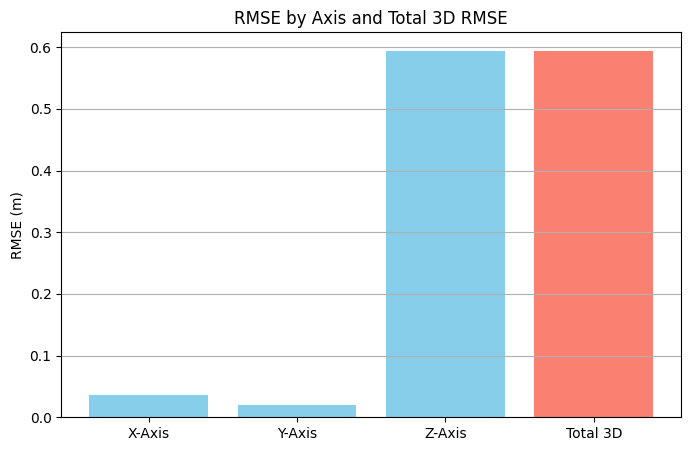

In [205]:
rmse(pid_hover)

#### **Straight Line Analytics**

Load data.

In [208]:
pid_line = load_data(1,1)
pid_line.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.000642,0.005488,0.001949,0.014470,0.0,0,0.8,0.164528,-0.741797,0.022744,1,0.005763,0.001678,0.014584
1,0.101887,0.006238,0.001283,0.014674,0.0,0,0.8,0.197461,-0.300475,-0.249180,1,0.006118,0.000786,0.016856
2,0.202246,0.005295,0.000237,0.033259,0.0,0,0.8,0.062156,4.993635,-0.341267,1,0.002689,0.000825,0.045404
3,0.302572,-0.006046,0.001408,0.090204,0.0,0,0.8,-0.505386,2.401952,-0.481648,1,-0.011023,0.002743,0.112102
4,0.403588,-0.023473,0.004620,0.173750,0.0,0,0.8,0.115609,0.040174,-0.970665,1,-0.029341,0.006451,0.201828


On 3D graph below we can see that CF instead of going straight up, it is drifting in the direction of trajectory.

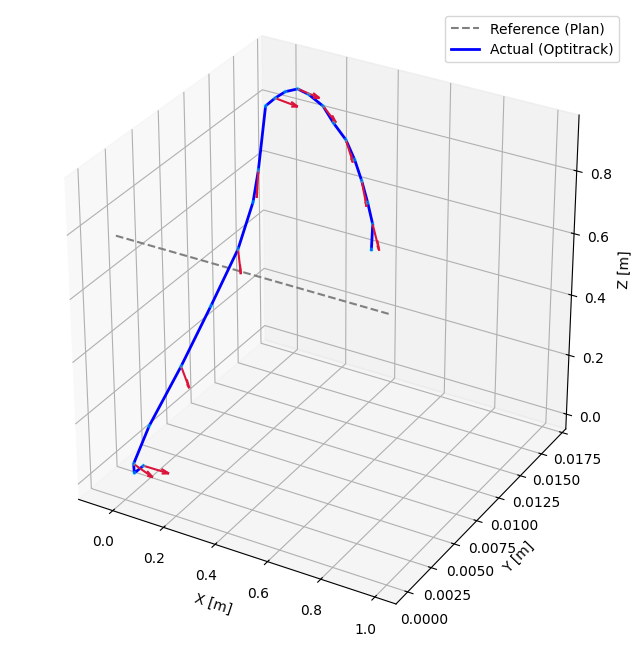

In [214]:
enhanced_visualise_planned_path_3D(pid_line) # type: ignore

In 2D analytics we can see more easily how controller is performing.

<br>**Top left graph** - CF tracks x axes perfectly with no oscilations in y.

<br>**Top right graph** - we see that y is approximately constant with small oscilations, meaning that controller is able to keep CF on target in y axes. For x axes we see dramatic spike, meaning around time 1s where z error decreases to 0, controller receives next point (1,0,0.8) which makes x error huge.

<br>**Bottom left graph** - we see that y axes response nonetheless has small oscilations. For x axes we can see clear gap between target and actual position, phase lag + accumulated error.

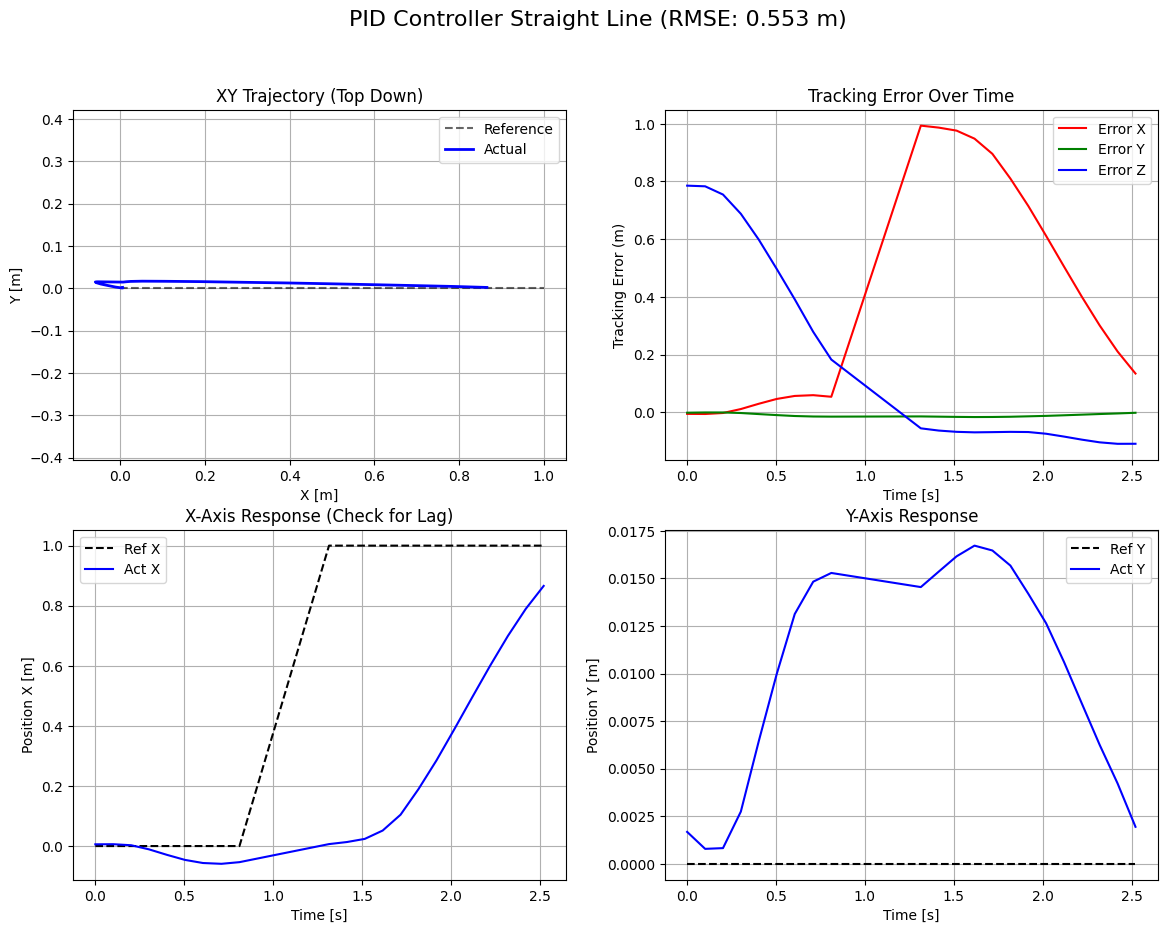

In [ ]:
dashboard(pid_line, "PID Controller Straight Line")

Total 3D RMSE:      0.6731 m
Max Tracking Error: 0.9952 m
Breakdown by Axis:
  X-Axis RMSE:      0.5533 m
  Y-Axis RMSE:      0.0115 m
  Z-Axis RMSE:      0.3831 m


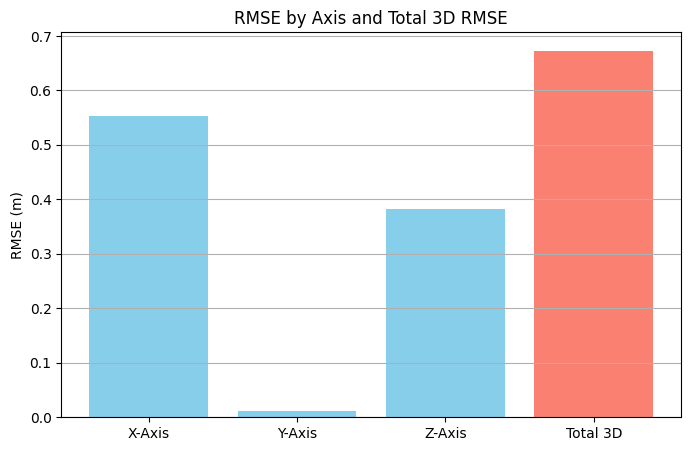

In [ ]:
rmse(pid_line)

#### **Sine Wave Analytics**

In [213]:
pid_sine = load_data(1,2)
pid_sine.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.000705,-0.004641,0.008648,0.014714,0.0,0.0,0.8,0.103722,-0.488758,0.008764,1,-0.004521,0.008348,0.014679
1,0.100938,-0.004787,0.007235,0.015430,0.0,0.0,0.8,0.342928,-0.140410,-0.012764,1,-0.005602,0.006067,0.017032
2,0.201539,-0.007426,0.004243,0.034524,0.0,0.0,0.8,0.121711,3.875689,-0.804709,1,-0.010129,0.004069,0.045501
3,0.302577,-0.018835,0.003869,0.089026,0.0,0.0,0.8,-0.588702,3.056588,-1.371656,1,-0.024215,0.004574,0.110159
4,0.403301,-0.036929,0.005916,0.170110,0.0,0.0,0.8,-0.316064,-0.996911,-1.884710,1,-0.042727,0.007471,0.197333


In 3D graph belowe we can see that from the position (0,0,0.8) CF overshoots the trajectory and then starts following it with some delay and deviation between referance.

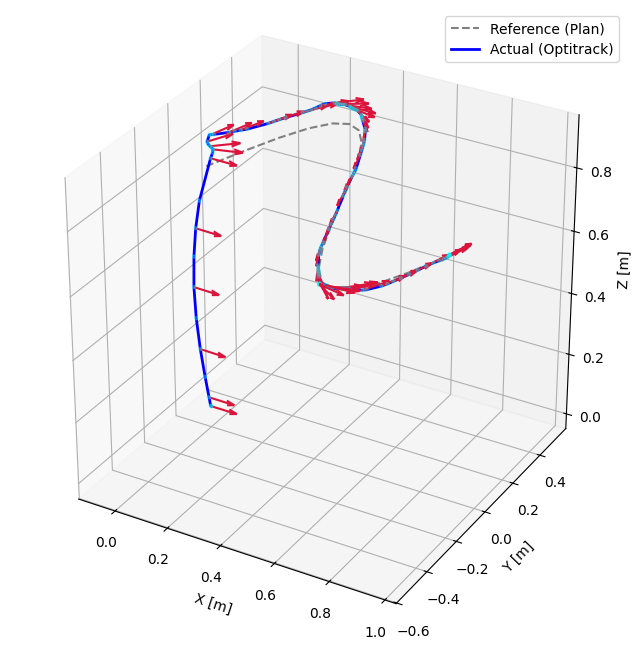

In [216]:
enhanced_visualise_planned_path_3D(pid_sine) # type: ignore

<br>**Top left graph** - we see that in x axes CF is able to track trajectory with small error

<br>**Top right graph** - in t=2s error z oscillates near 0 -> means that CF reached target altitude. Then by y error we can see that each time the new command was send the more the error increases. X is not constant -> each peak it was sended new command.

<br>**Bottom graphs** - y response perfetly mirrows the desired trajectory just with dellay of ~1s. X response is even smoother than referance one.

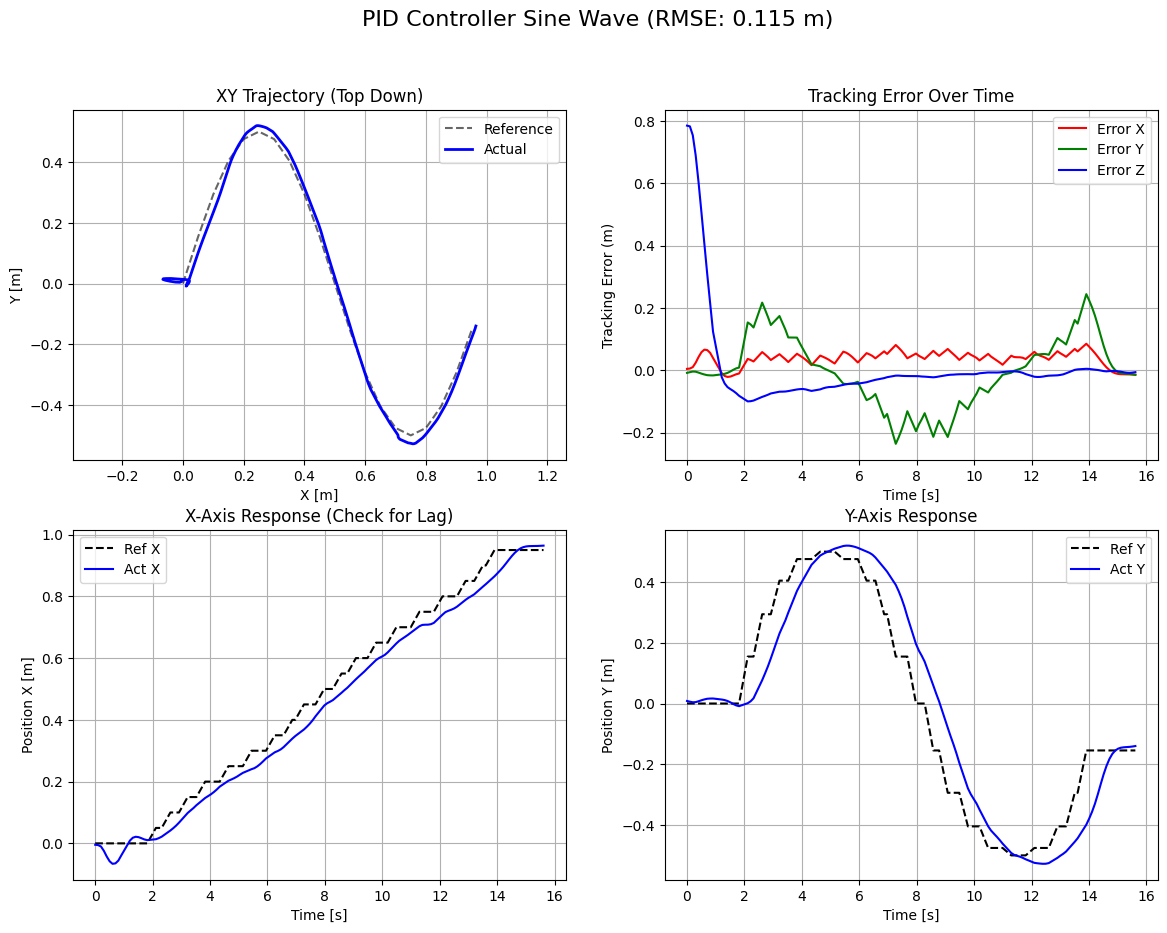

In [ ]:
dashboard(pid_sine, "PID Controller Sine Wave")

Total 3D RMSE:      0.2059 m
Max Tracking Error: 0.7854 m
Breakdown by Axis:
  X-Axis RMSE:      0.0437 m
  Y-Axis RMSE:      0.1063 m
  Z-Axis RMSE:      0.1708 m


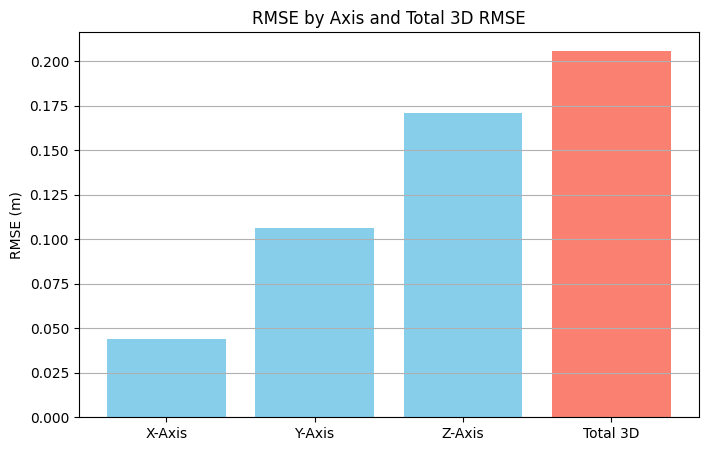

In [218]:
rmse(pid_sine)

#### **Figure Eight Analytics**

In [219]:
pid_figure8 = load_data(1,3)
pid_figure8.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.001163,0.011981,0.009433,0.014900,0.0,0.0,0.8,0.155527,-0.540746,0.031363,1,0.012338,0.009368,0.014843
1,0.102166,0.012254,0.009225,0.015592,0.0,0.0,0.8,0.610404,0.184217,-0.123113,1,0.011265,0.008691,0.016726
2,0.202874,0.009009,0.008686,0.030417,0.0,0.0,0.8,-0.481093,5.451409,-0.594020,1,0.005612,0.009529,0.041344
3,0.303362,-0.005266,0.010224,0.084367,0.0,0.0,0.8,0.295131,1.939572,-1.174906,1,-0.010165,0.012221,0.103740
4,0.404249,-0.024067,0.014051,0.163259,0.0,0.0,0.8,-0.408531,-1.001396,-1.662296,1,-0.030093,0.016260,0.188709


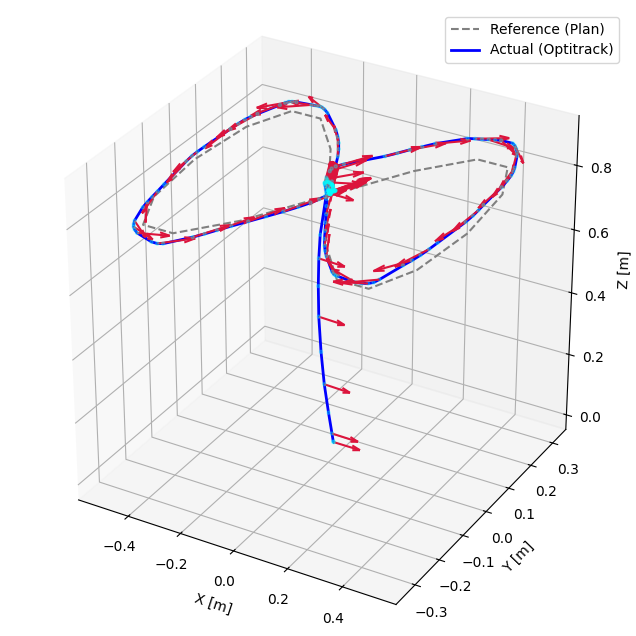

In [220]:
enhanced_visualise_planned_path_3D(pid_figure8) # type: ignore

<br>**XY Trajectory** - shape of 8 figure curve is much wider. COntroller struggles more at turns.

<br>**Tracking error over time** - the x y errors oscilate approximately by $\pm 0.2\text{m}$. 

* -> x/y - every time CF is required to make a sharp turn or change direction quickly we can see the error spikes -> "Reference" position is moving faster than the drone can keep up with. 

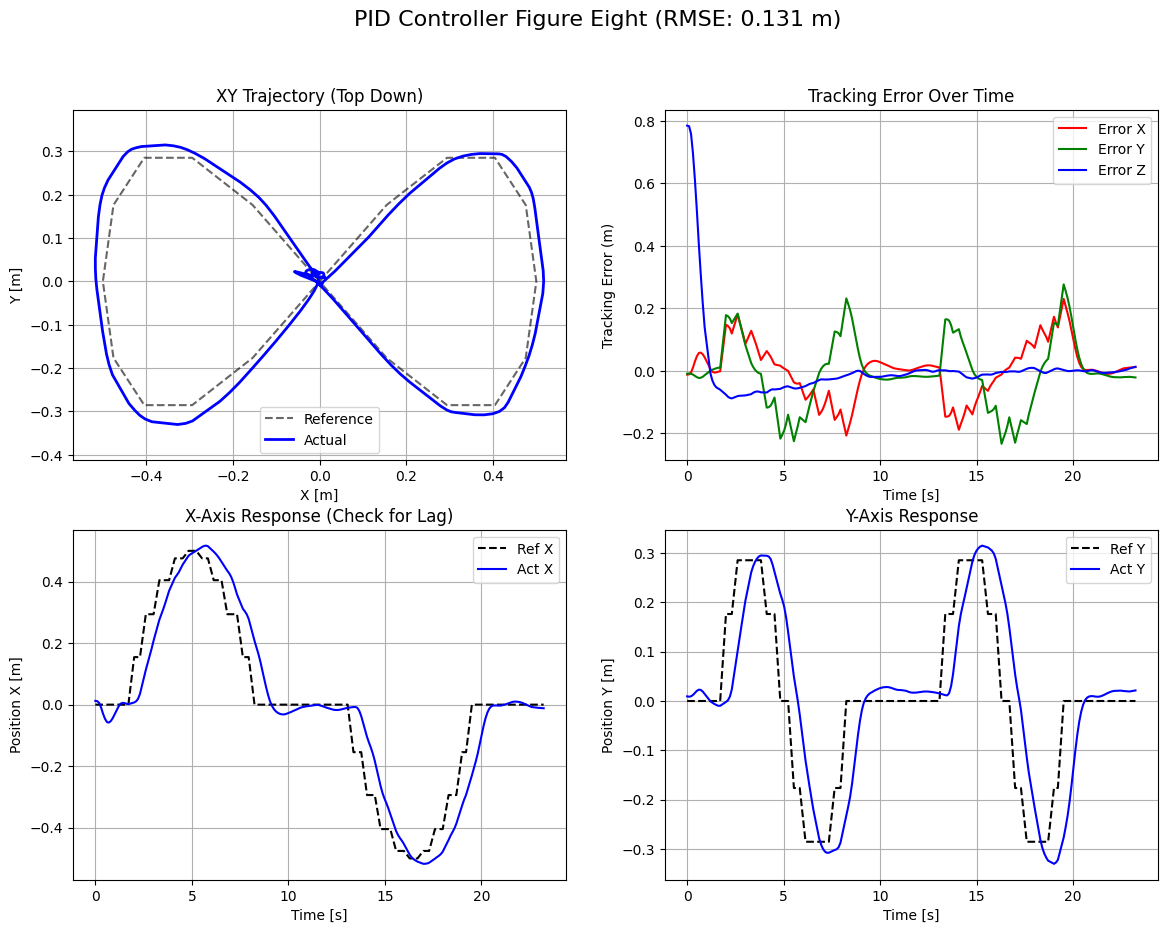

In [222]:
dashboard(pid_figure8, "PID Controller Figure Eight")

Total 3D RMSE:      0.1875 m
Max Tracking Error: 0.7853 m
Breakdown by Axis:
  X-Axis RMSE:      0.0815 m
  Y-Axis RMSE:      0.1022 m
  Z-Axis RMSE:      0.1344 m


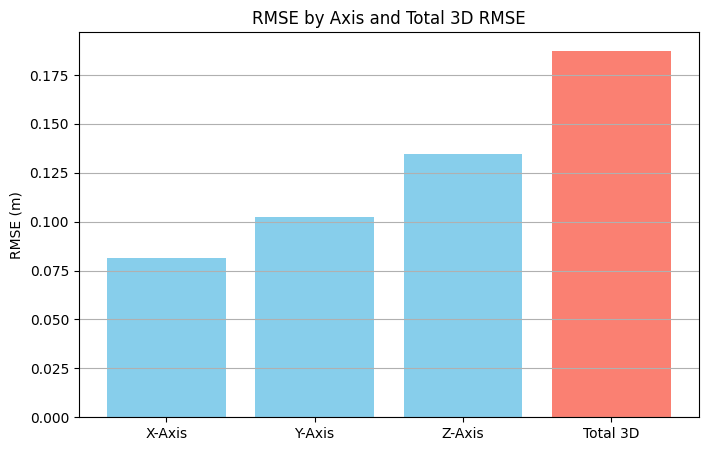

In [223]:
rmse(pid_figure8)

## Mellinger

#### **Hover Analytics**

In [224]:
mel_hover = load_data(2,0)
mel_hover.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.000238,-0.025238,-0.001156,0.771796,0,0,0.8,-0.223452,-0.323079,-0.606016,2,-0.024504,-0.001362,0.771251
1,0.504525,-0.016310,-0.003838,0.772660,0,0,0.8,-0.343040,0.533109,-0.604090,2,-0.015437,-0.004659,0.773149


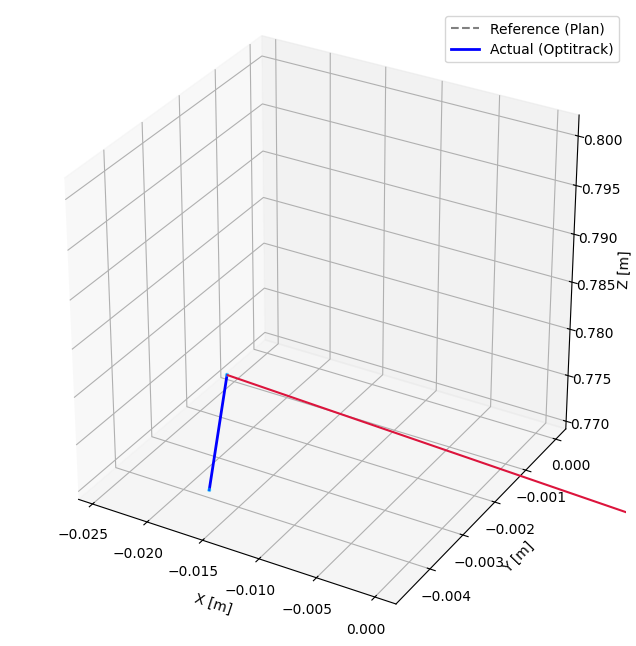

In [229]:
enhanced_visualise_planned_path_3D(mel_hover) # type: ignore

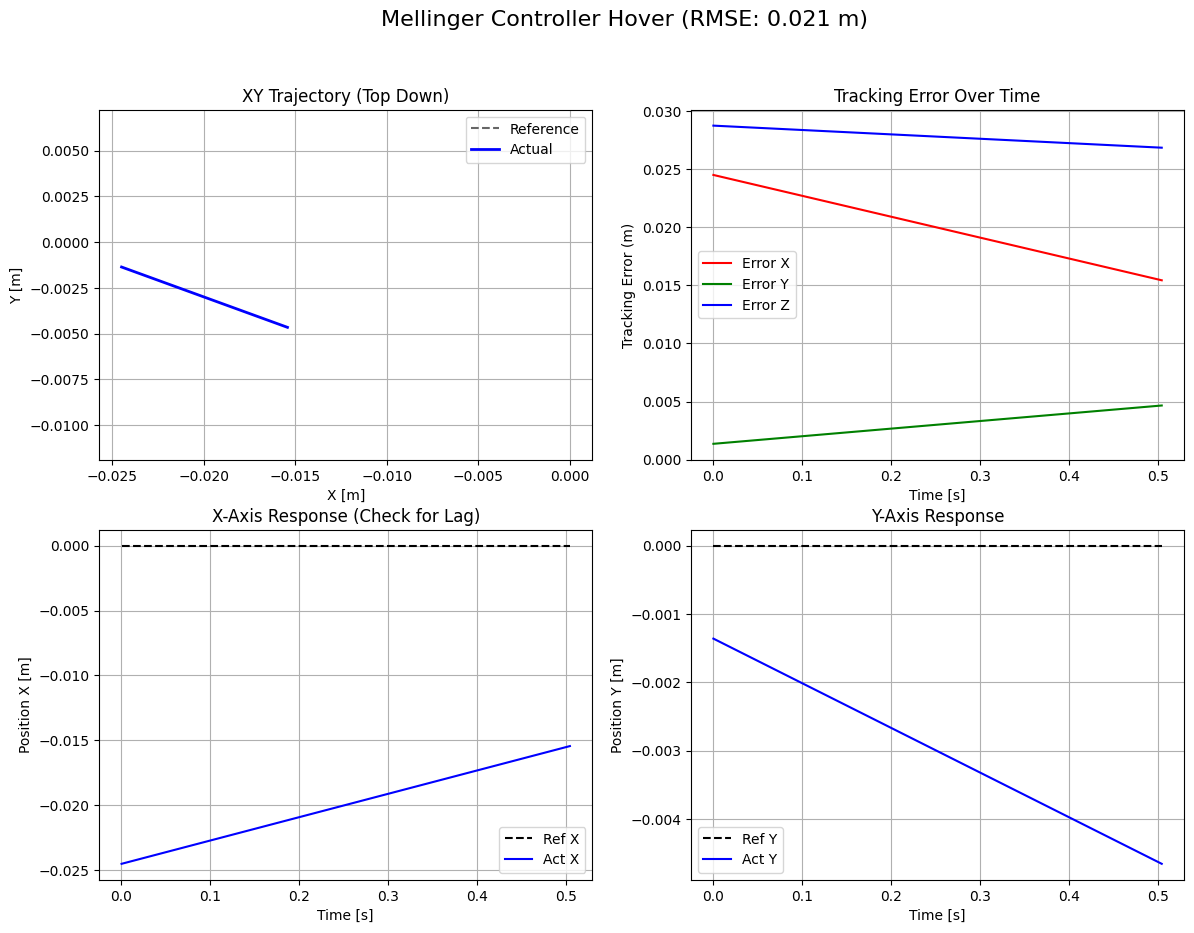

In [230]:
dashboard(mel_hover, "Mellinger Controller Hover")

Total 3D RMSE:      0.0347 m
Max Tracking Error: 0.0378 m
Breakdown by Axis:
  X-Axis RMSE:      0.0205 m
  Y-Axis RMSE:      0.0034 m
  Z-Axis RMSE:      0.0278 m


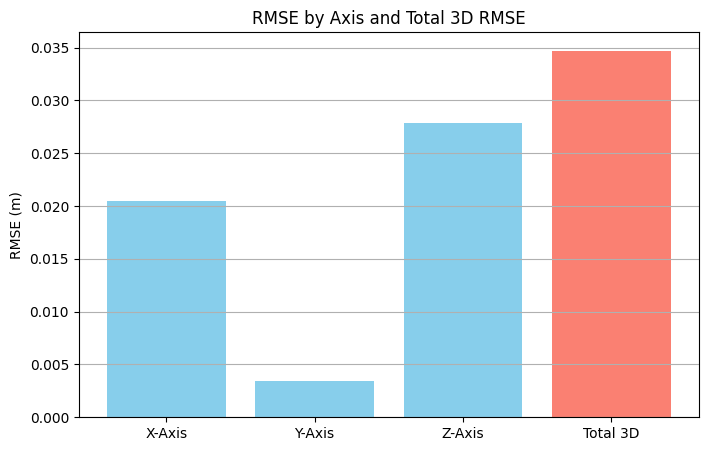

In [231]:
rmse(mel_hover)

#### **Straight Line Analytics**

In [225]:
mel_line = load_data(2,1)
mel_line.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.000242,-0.020895,-0.001849,0.767243,0.0,0,0.8,-0.214434,-0.402109,-0.341116,2,-0.020559,-0.002244,0.766306
1,0.500954,-0.016379,-0.001045,0.773919,0.0,0,0.8,-0.062786,0.209311,-0.400299,2,-0.016127,-0.001186,0.772672
2,1.001416,-0.015916,0.000122,0.772686,1.0,0,0.8,-0.100536,0.183237,-0.346139,2,-0.015640,-0.000367,0.773378


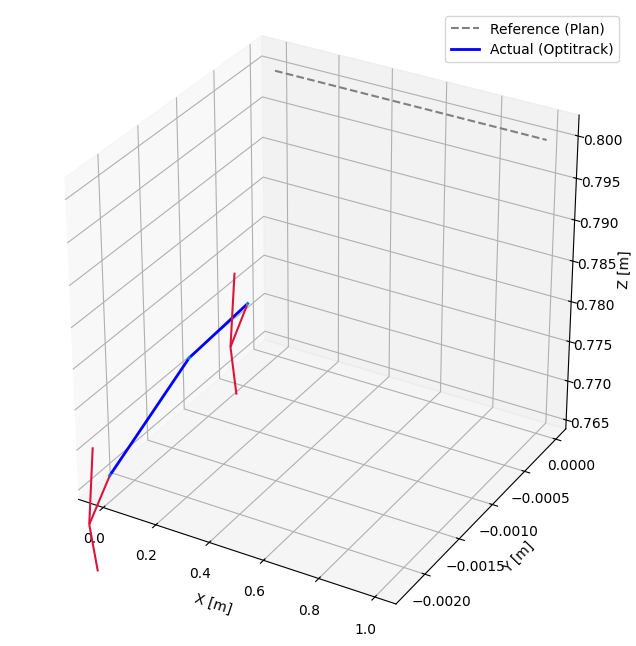

In [232]:
enhanced_visualise_planned_path_3D(mel_line) # type: ignore


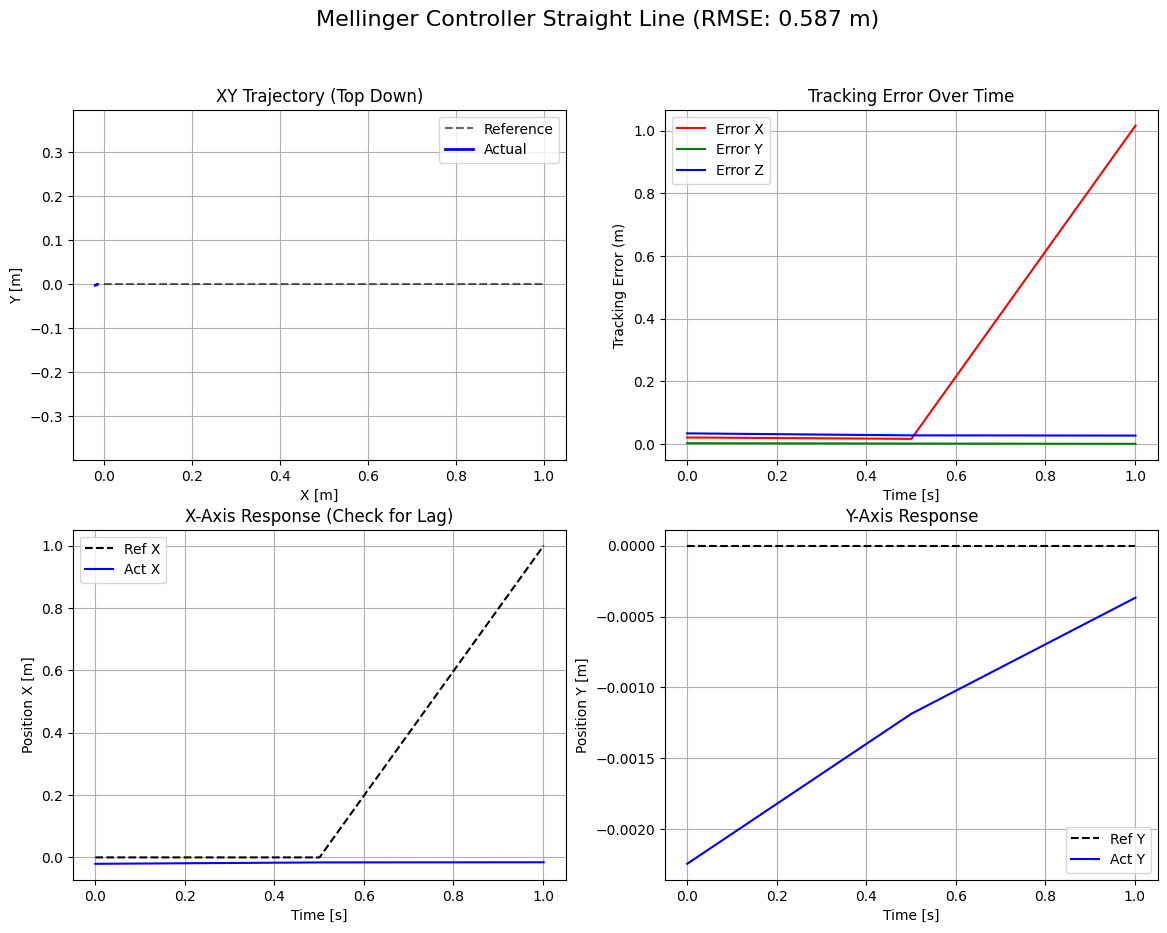

In [233]:
dashboard(mel_line, "Mellinger Controller Straight Line")


Total 3D RMSE:      0.5873 m
Max Tracking Error: 1.0160 m
Breakdown by Axis:
  X-Axis RMSE:      0.5866 m
  Y-Axis RMSE:      0.0015 m
  Z-Axis RMSE:      0.0294 m


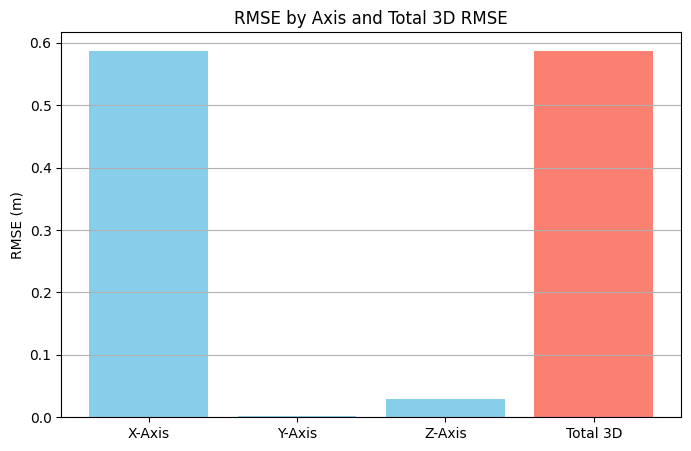

In [234]:
rmse(mel_line)

#### **Sine Wave Analytics**

In [235]:
mel_sine = load_data(2,2)
mel_sine.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.000498,-0.021120,0.009407,0.771065,0.00,0.000000,0.8,0.205216,-0.388797,-0.247493,2,-0.021424,0.009234,0.769583
1,0.501431,-0.017049,0.008497,0.769087,0.00,0.000000,0.8,-0.050163,0.311626,-0.263392,2,-0.017013,0.008541,0.769176
2,1.002572,-0.015252,0.009077,0.777181,0.05,0.154508,0.8,0.144862,0.092031,-0.221373,2,-0.014447,0.009294,0.775535
3,1.503242,0.007927,0.069025,0.776707,0.10,0.293893,0.8,-1.372275,-0.210052,-0.295755,2,0.010965,0.077029,0.776566
4,2.004107,0.057092,0.211000,0.773474,0.15,0.404508,0.8,1.737050,0.778684,-0.340366,2,0.061103,0.220394,0.773151


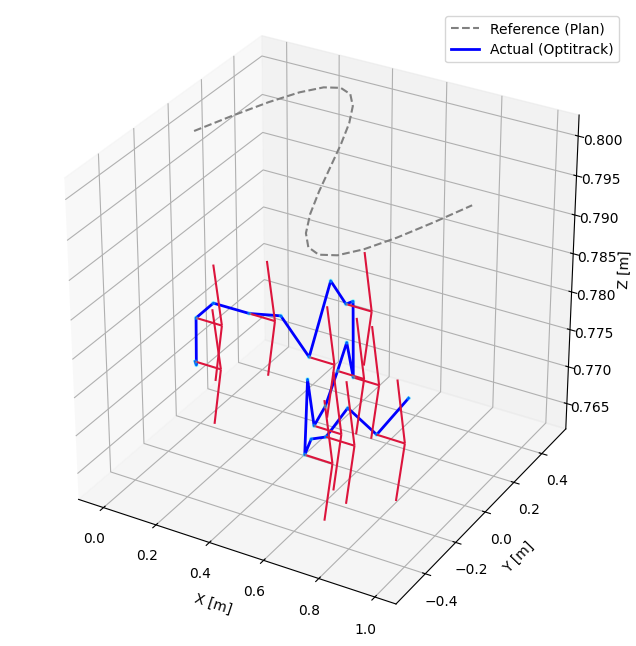

In [236]:
enhanced_visualise_planned_path_3D(mel_sine) # type: ignore


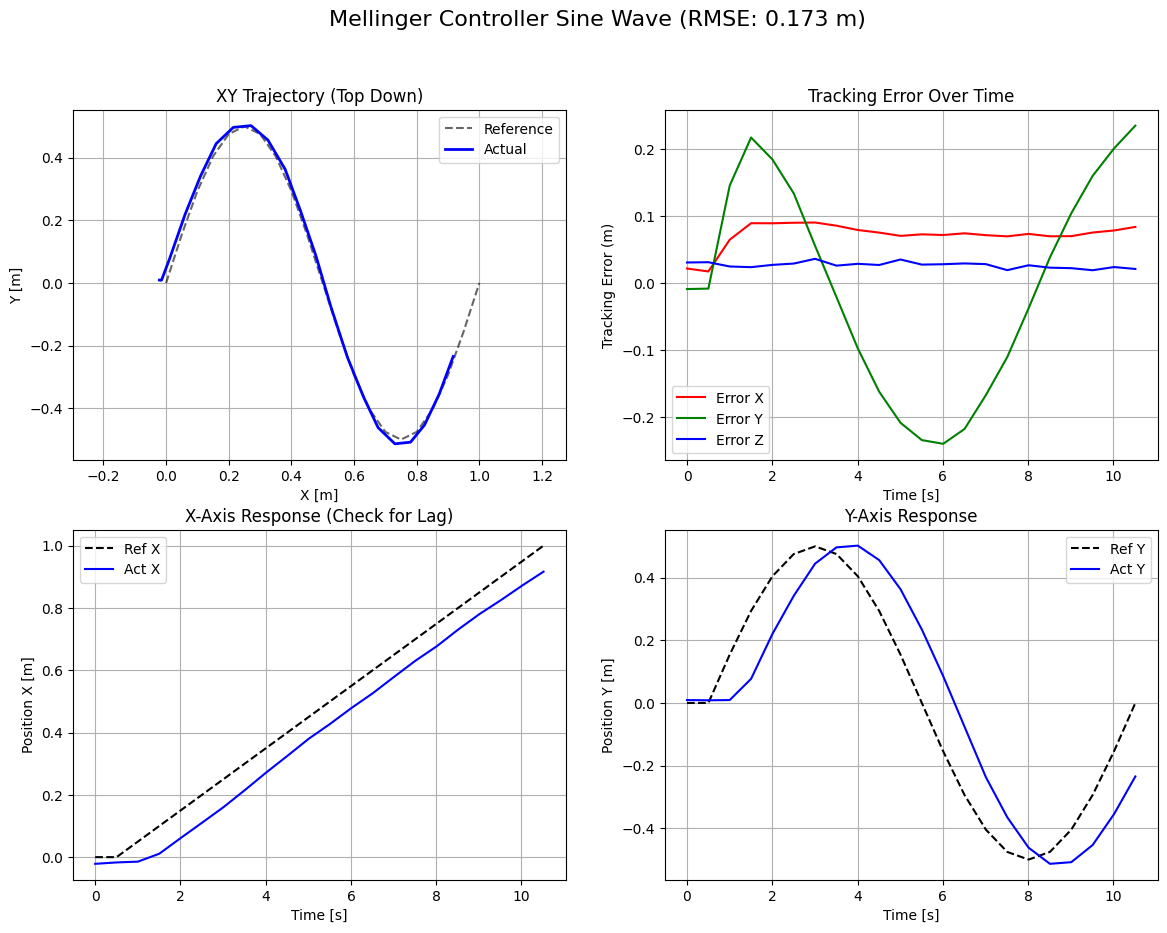

In [283]:
dashboard(mel_sine, "Mellinger Controller Sine Wave")


Total 3D RMSE:      0.1750 m
Max Tracking Error: 0.2520 m
Breakdown by Axis:
  X-Axis RMSE:      0.0740 m
  Y-Axis RMSE:      0.1563 m
  Z-Axis RMSE:      0.0268 m


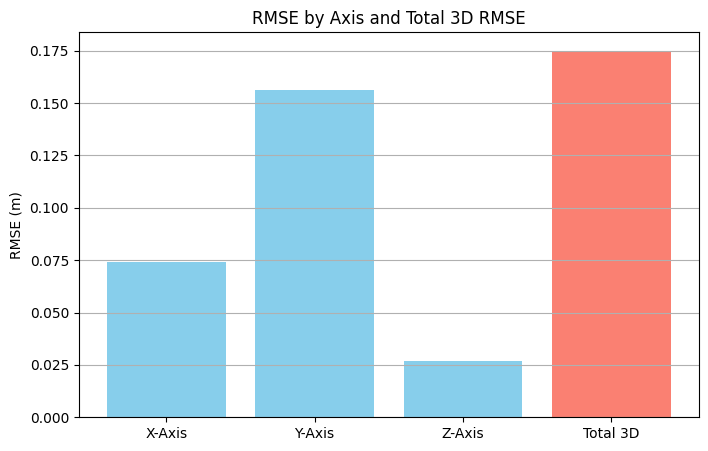

In [238]:
rmse(mel_sine)

#### **Figure 8 Analytics**

In [239]:
mel_figure8 = load_data(2,3)
mel_figure8.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.000079,-0.004566,0.000476,0.764749,0.000000,0.000000,0.8,-0.377377,0.033184,-1.413401,2,-0.004203,0.000241,0.764088
1,0.500845,-0.006534,-0.000264,0.773097,0.000000,0.000000,0.8,-0.011148,0.106052,-1.113969,2,-0.006813,-0.001097,0.771324
2,1.001511,-0.009771,-0.007991,0.769781,0.154508,0.176336,0.8,-0.657231,0.328829,-1.029296,2,-0.009067,-0.008453,0.769550
3,1.502203,0.051352,0.058294,0.771584,0.293893,0.285317,0.8,-2.581812,-1.301935,-1.044946,2,0.063830,0.070668,0.770507
4,2.002880,0.195783,0.217048,0.767062,0.404508,0.285317,0.8,2.496433,1.412688,-0.888798,2,0.204994,0.226489,0.765369


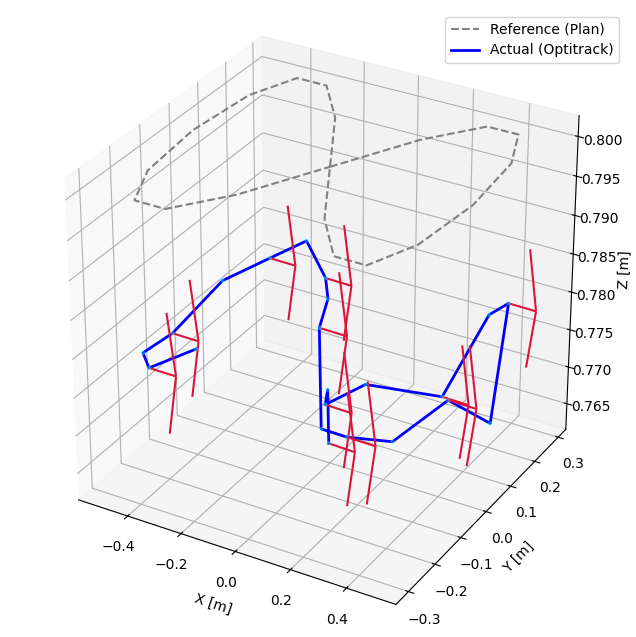

In [240]:
enhanced_visualise_planned_path_3D(mel_figure8) # type: ignore


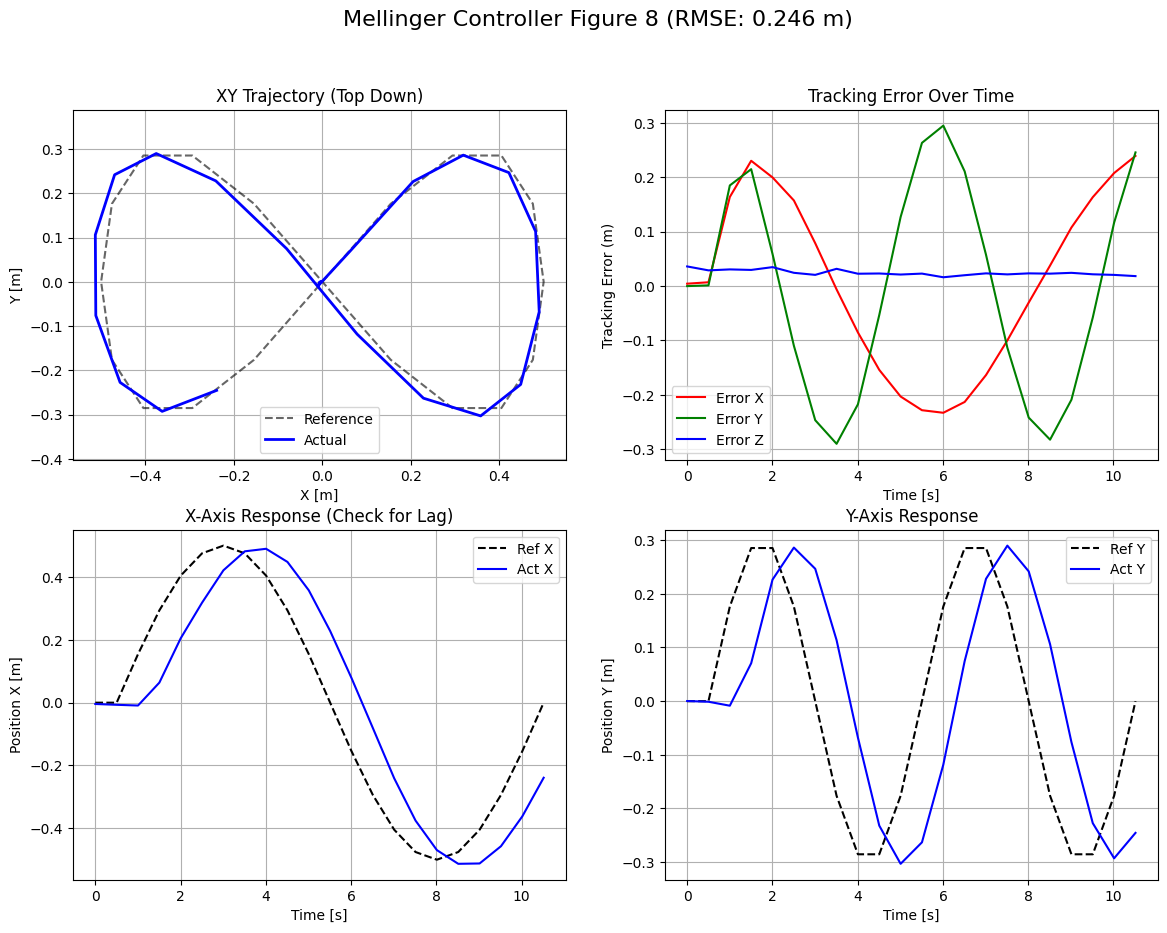

In [284]:
dashboard(mel_figure8, "Mellinger Controller Figure 8")


Total 3D RMSE:      0.2476 m
Max Tracking Error: 0.3760 m
Breakdown by Axis:
  X-Axis RMSE:      0.1584 m
  Y-Axis RMSE:      0.1886 m
  Z-Axis RMSE:      0.0248 m


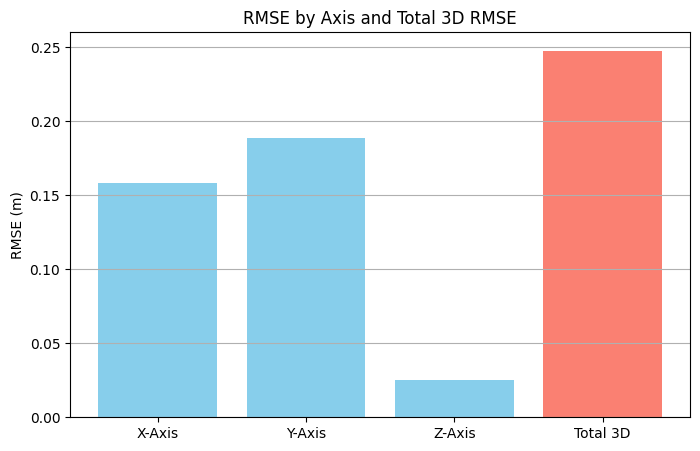

In [242]:
rmse(mel_figure8)

## INDI

#### **Hover Analytics**

In [244]:
indi_hover = load_data(3,0)
indi_hover.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.002248,0.005488,0.001211,0.015099,0,0,0.8,0.189806,-0.566878,0.032305,3,0.005640,0.001023,0.015153
1,0.102914,0.005940,0.000869,0.015157,0,0,0.8,0.091236,-0.554177,-0.068312,3,0.005938,0.000698,0.015342
2,0.203529,0.006472,0.000587,0.015465,0,0,0.8,-0.072252,-0.635623,-0.230064,3,0.006126,0.000780,0.017469
3,0.304123,0.005126,0.001079,0.032982,0,0,0.8,0.716249,6.446506,-0.290306,3,0.002219,0.001786,0.042645
4,0.405037,-0.008712,0.002501,0.075444,0,0,0.8,-1.269328,8.122641,-0.146000,3,-0.015683,0.003970,0.091803


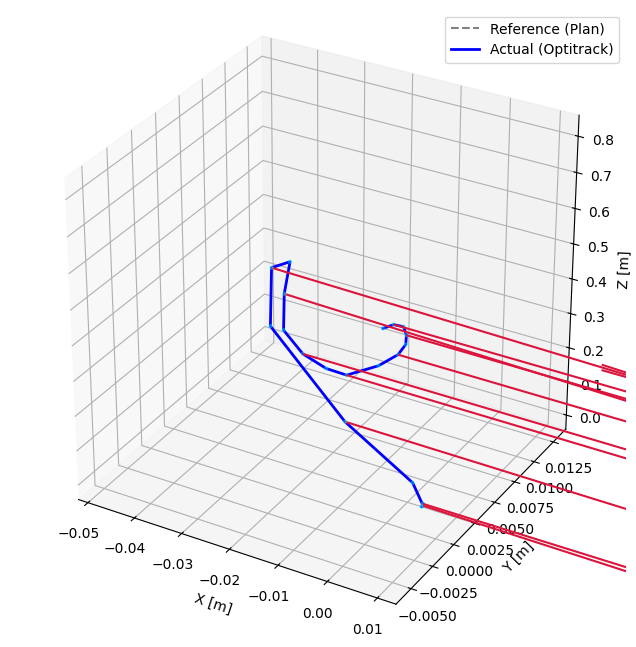

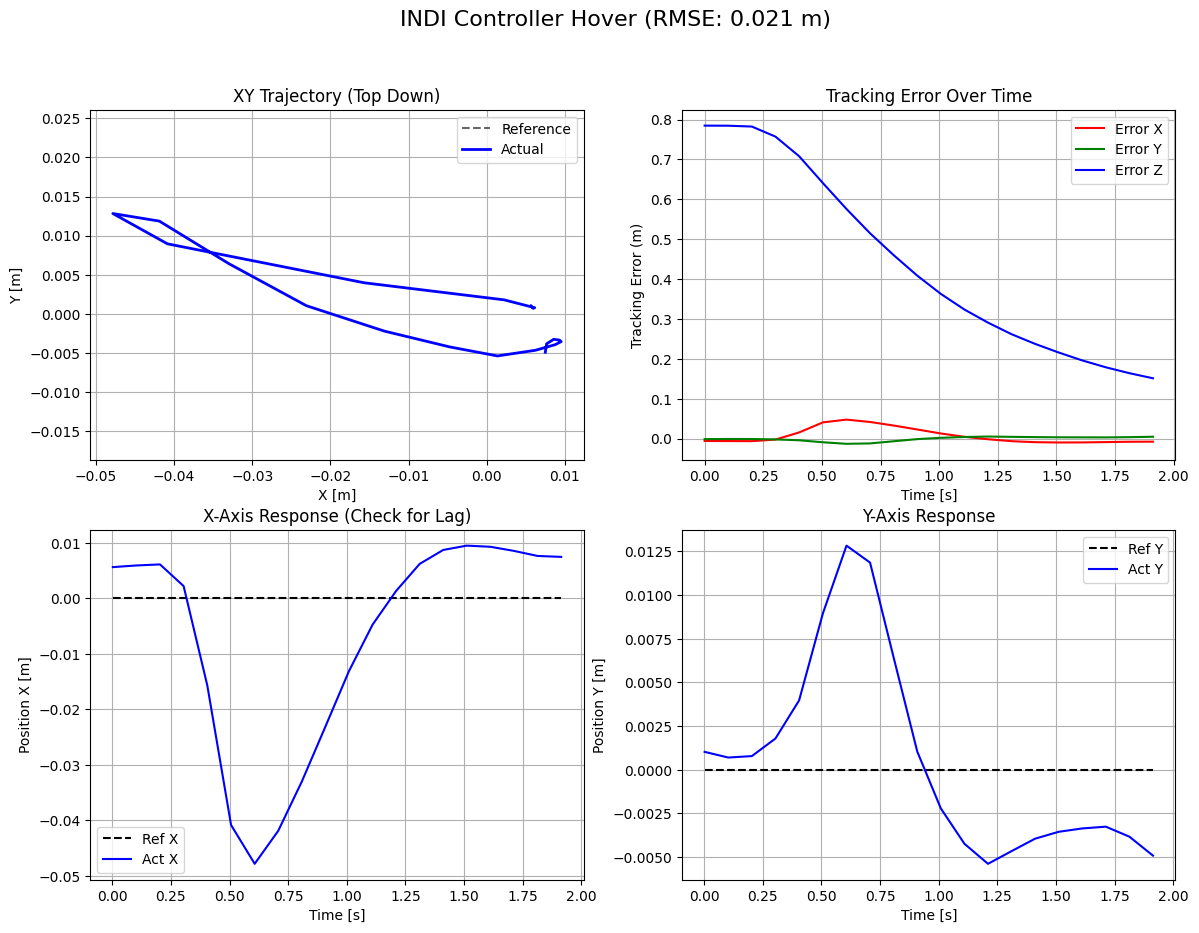

Total 3D RMSE:      0.4964 m
Max Tracking Error: 0.7849 m
Breakdown by Axis:
  X-Axis RMSE:      0.0205 m
  Y-Axis RMSE:      0.0055 m
  Z-Axis RMSE:      0.4959 m


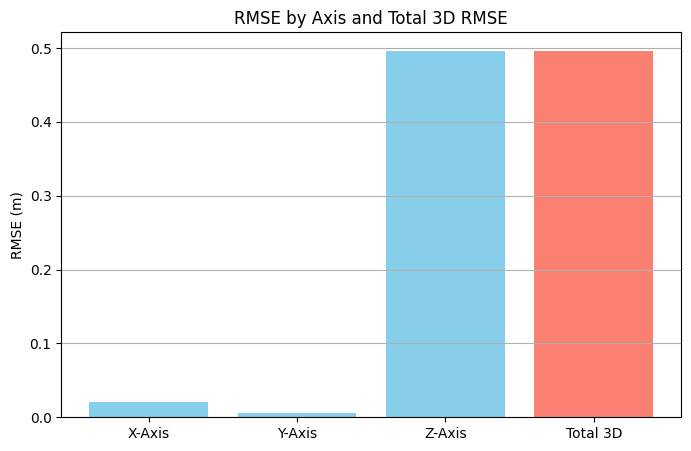

In [285]:
enhanced_visualise_planned_path_3D(indi_hover) # type: ignore
dashboard(indi_hover, "INDI Controller Hover")
rmse(indi_hover)

#### **Straight Line**

In [245]:
indi_line= load_data(3,1)
indi_line.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.001080,0.007585,0.004426,0.015222,0.0,0,0.8,0.347639,-0.463291,0.005494,3,0.007786,0.004268,0.015284
1,0.102375,0.007911,0.004190,0.015140,0.0,0,0.8,0.491329,-0.414001,0.124897,3,0.007888,0.004305,0.015206
2,0.203193,0.007954,0.003958,0.016116,0.0,0,0.8,0.642000,0.100361,0.091610,3,0.007331,0.004106,0.018447
3,0.303843,0.006349,0.003447,0.031160,0.0,0,0.8,-0.977852,4.054293,-0.258058,3,0.003228,0.004512,0.043152
4,0.404223,-0.003896,0.006164,0.072621,0.0,0,0.8,-3.301535,5.829078,-0.228906,3,-0.011168,0.008298,0.094285


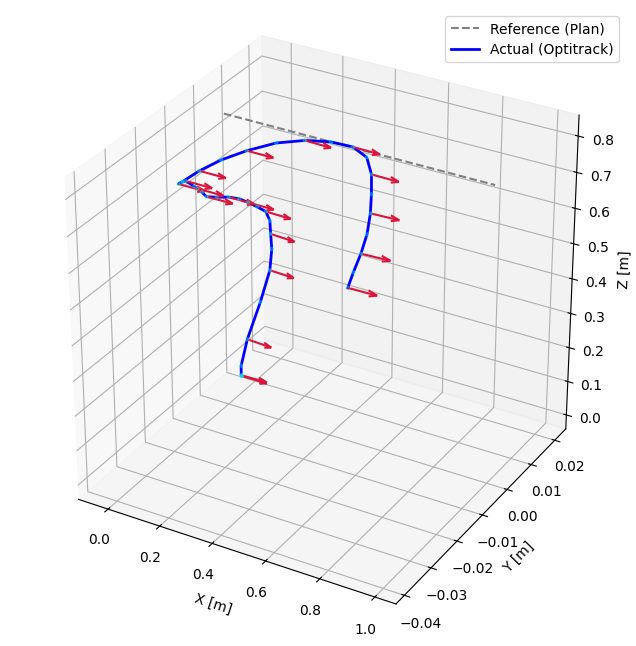

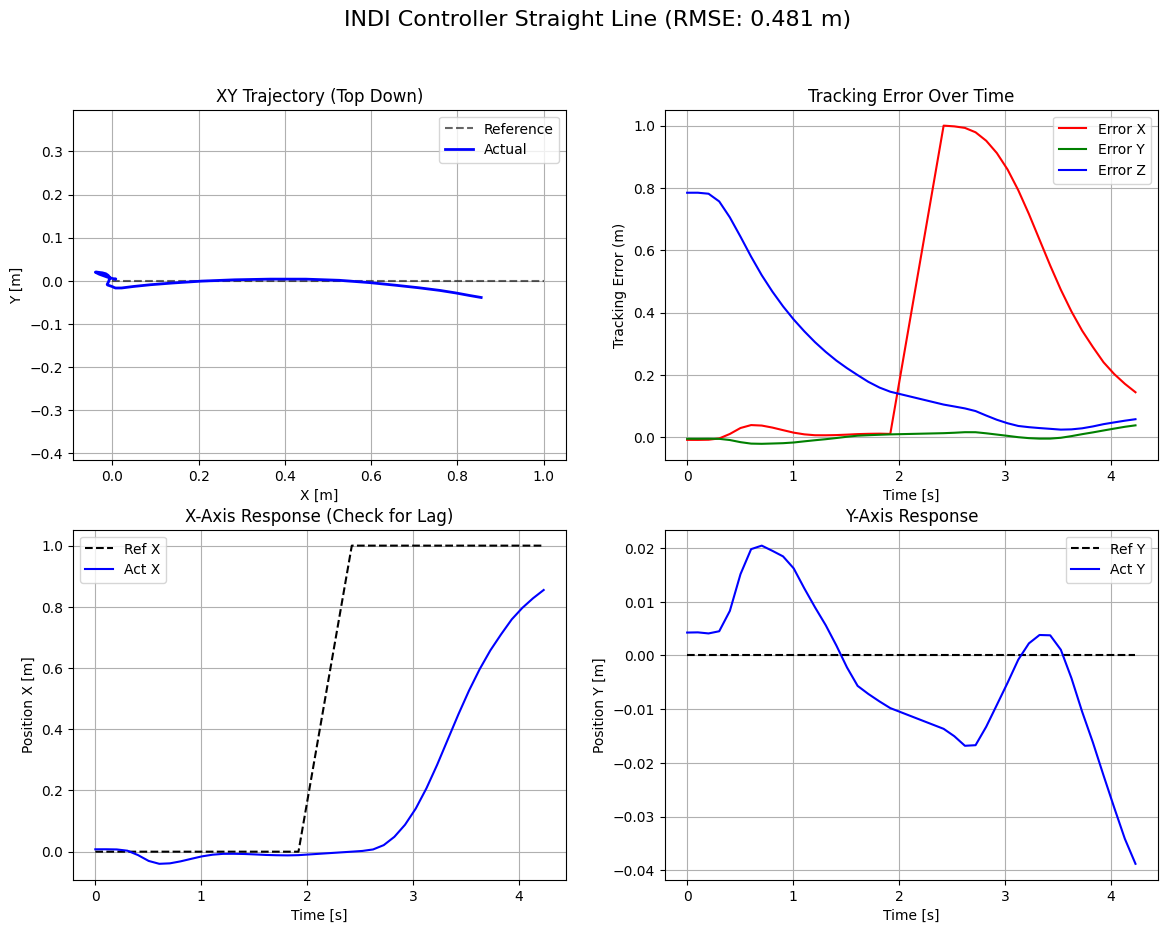

Total 3D RMSE:      0.6006 m
Max Tracking Error: 1.0056 m
Breakdown by Axis:
  X-Axis RMSE:      0.4806 m
  Y-Axis RMSE:      0.0146 m
  Z-Axis RMSE:      0.3599 m


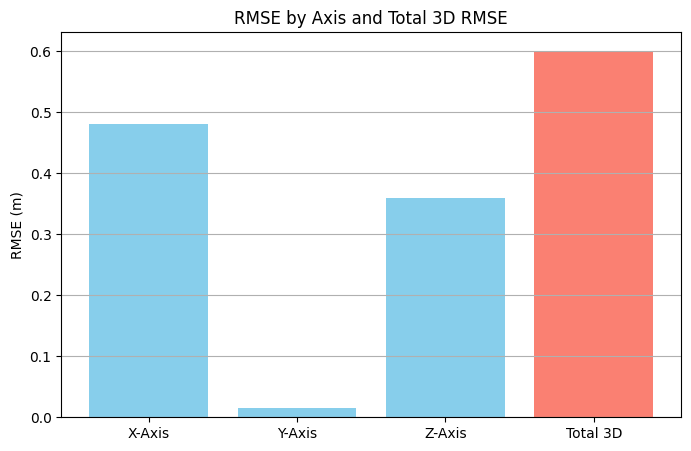

In [286]:
enhanced_visualise_planned_path_3D(indi_line) # type: ignore
dashboard(indi_line, "INDI Controller Straight Line")
rmse(indi_line)

#### **Sine Wave**

In [246]:
indi_sine= load_data(3,2)
indi_sine.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.000419,0.013464,-0.008347,0.015324,0.0,0.0,0.8,0.104136,-0.519847,0.016107,3,0.013722,-0.008416,0.015265
1,0.100741,0.013897,-0.008400,0.015368,0.0,0.0,0.8,0.168975,-0.503526,-0.023154,3,0.013817,-0.008362,0.015198
2,0.202319,0.014214,-0.008429,0.015629,0.0,0.0,0.8,-0.088157,-0.686498,-0.100711,3,0.013920,-0.008283,0.015814
3,0.302834,0.013266,-0.007730,0.023416,0.0,0.0,0.8,-1.721511,4.938105,0.194064,3,0.010051,-0.006249,0.027502
4,0.403589,-0.000388,-0.002620,0.051764,0.0,0.0,0.8,-2.115321,11.299047,0.176104,3,-0.011583,0.002790,0.068246


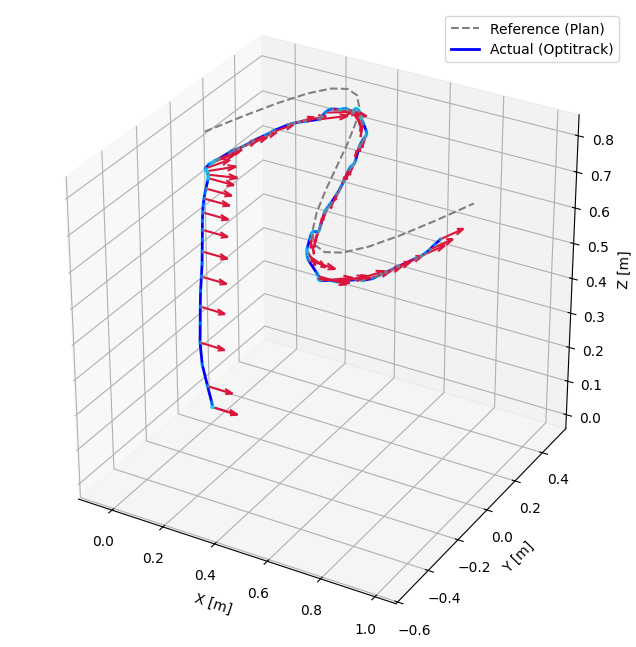

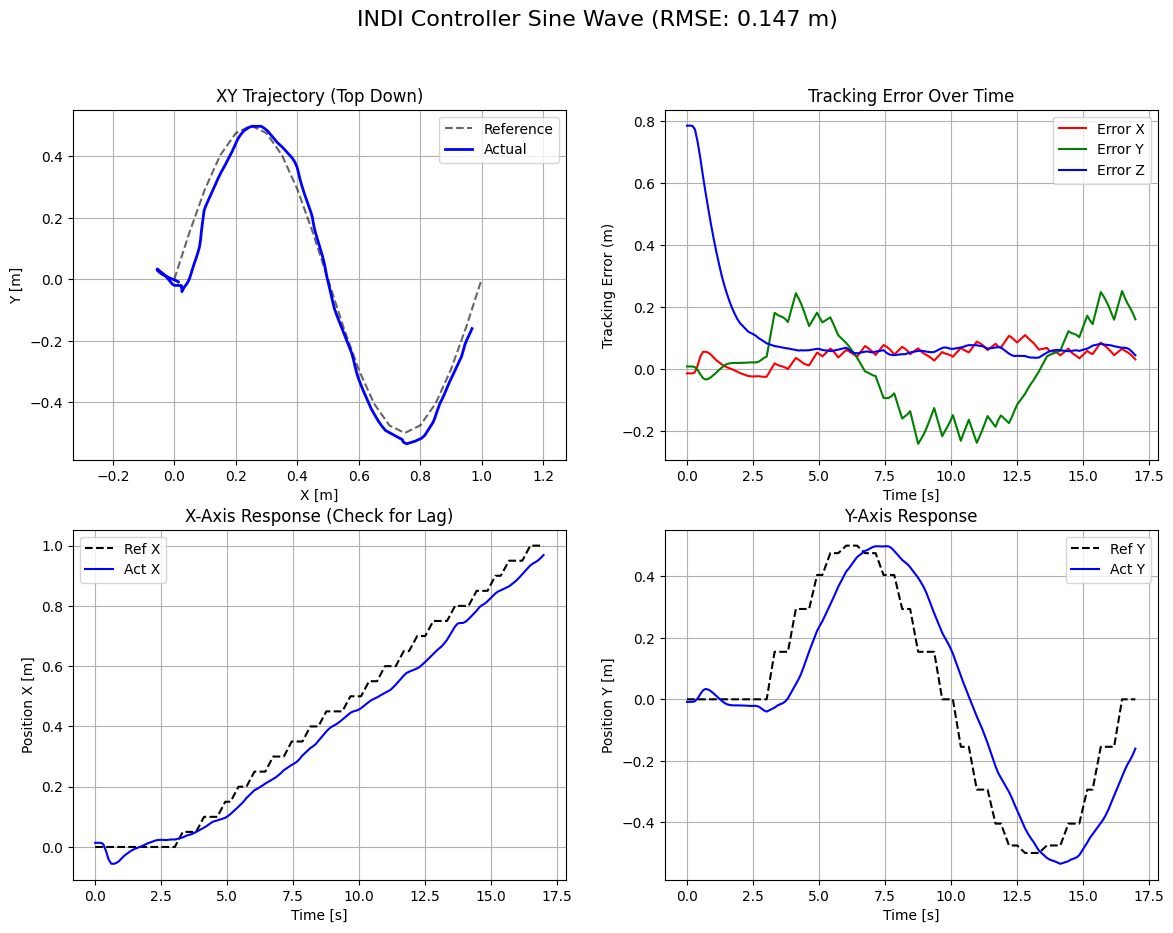

Total 3D RMSE:      0.2613 m
Max Tracking Error: 0.7850 m
Breakdown by Axis:
  X-Axis RMSE:      0.0540 m
  Y-Axis RMSE:      0.1368 m
  Z-Axis RMSE:      0.2159 m


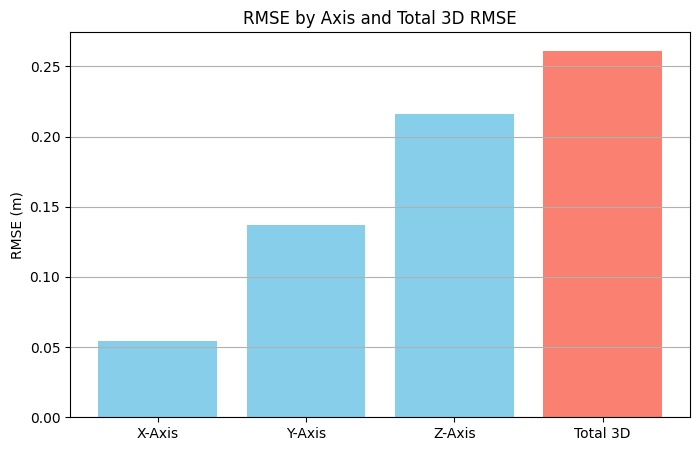

In [287]:
enhanced_visualise_planned_path_3D(indi_sine) # type: ignore
dashboard(indi_sine, "INDI Controller Sine Wave")
rmse(indi_sine)

#### **Figure 8**

In [248]:
indi_figure8 = load_data(3,3)
indi_figure8.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.000929,0.005477,0.004532,0.014877,0.0,0.0,0.8,0.204001,-0.589255,-0.025691,3,0.005698,0.004488,0.014898
1,0.101361,0.005693,0.004574,0.014857,0.0,0.0,0.8,0.196794,-0.552459,-0.312605,3,0.005359,0.004768,0.014927
2,0.201694,0.005767,0.004498,0.014836,0.0,0.0,0.8,0.203166,-0.463809,-0.363068,3,0.005148,0.004720,0.015619
3,0.302215,0.004540,0.004723,0.023956,0.0,0.0,0.8,-0.037017,3.394665,-0.620974,3,0.002292,0.005558,0.030861
4,0.403652,-0.004634,0.006312,0.058642,0.0,0.0,0.8,-0.473815,6.702604,-0.158380,3,-0.009986,0.007002,0.072682


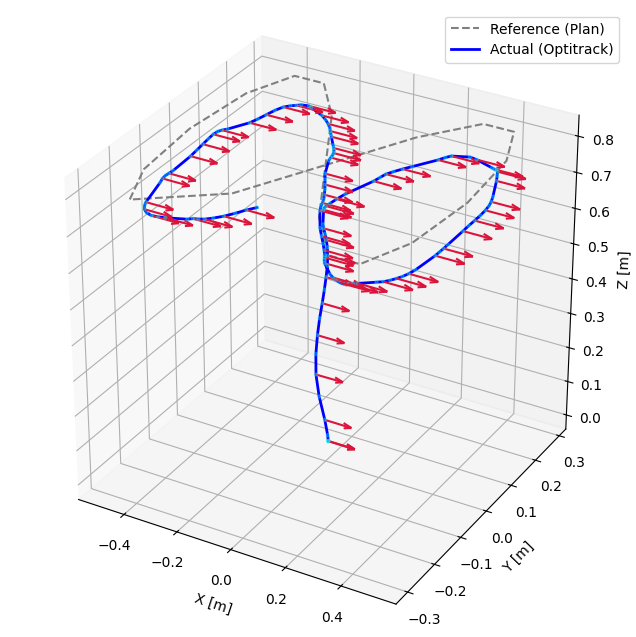

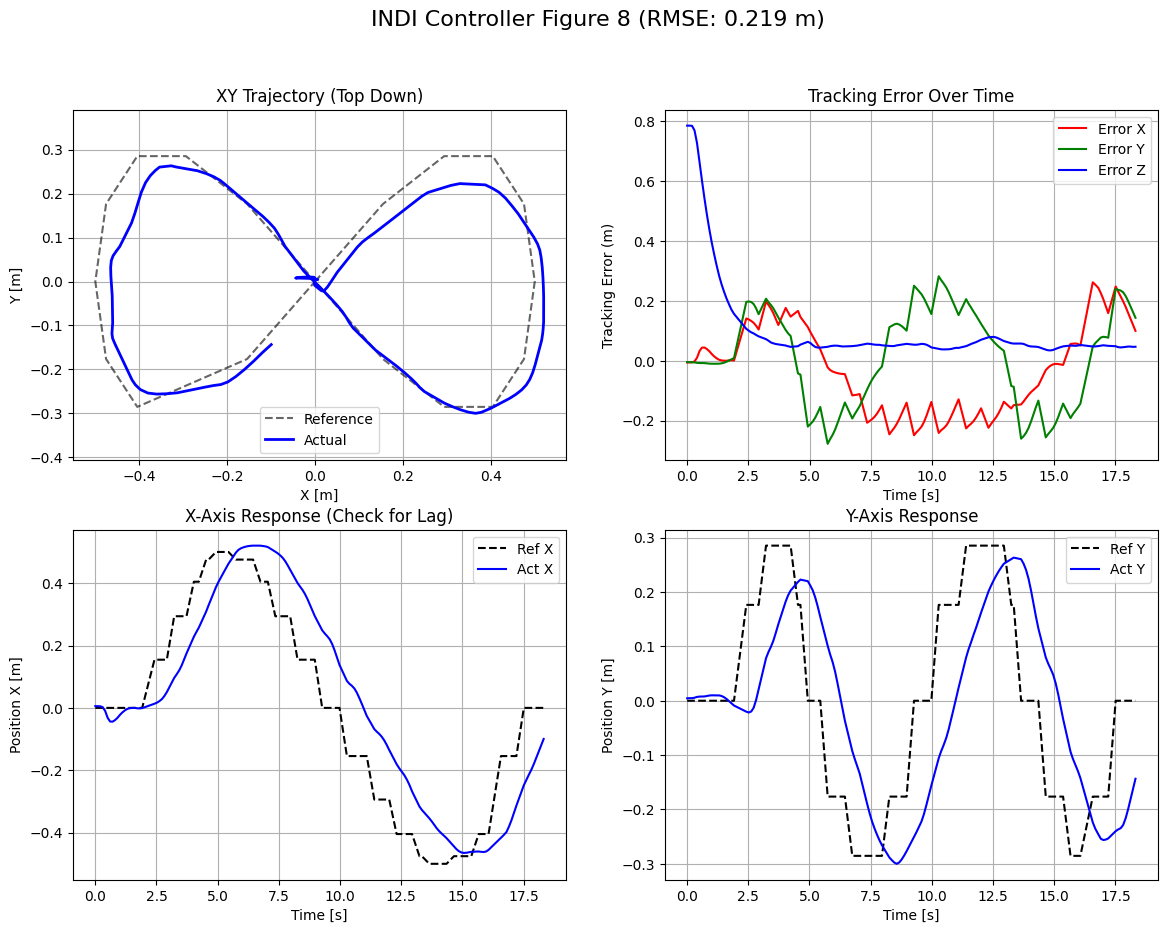

Total 3D RMSE:      0.2962 m
Max Tracking Error: 0.7851 m
Breakdown by Axis:
  X-Axis RMSE:      0.1484 m
  Y-Axis RMSE:      0.1608 m
  Z-Axis RMSE:      0.1996 m


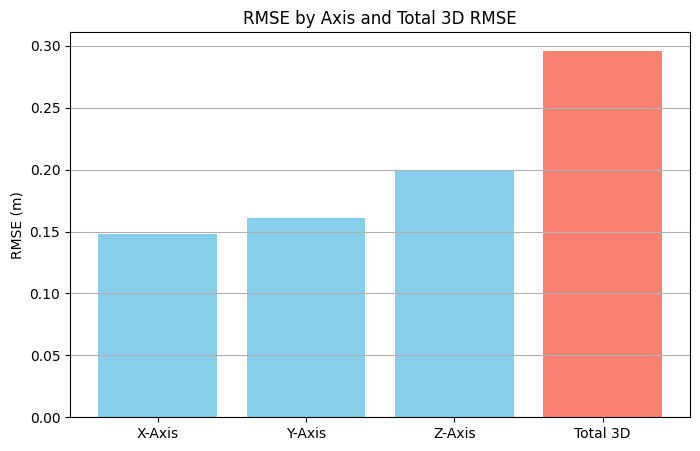

In [288]:
enhanced_visualise_planned_path_3D(indi_figure8) # type: ignore
dashboard(indi_figure8, "INDI Controller Figure 8")
rmse(indi_figure8)

## Brescianini

#### **Hover**

In [253]:
bres_hover = load_data(4,0)
bres_hover.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.003397,-0.007856,-0.001630,0.014020,0,0,0.8,0.235317,-0.332839,0.004084,4,-0.007841,-0.002101,0.013806
1,0.104589,-0.007748,-0.001963,0.013937,0,0,0.8,0.321248,-0.220593,-0.206000,4,-0.009043,-0.002528,0.018721
2,0.205126,-0.008735,-0.002650,0.019287,0,0,0.8,1.302577,3.444424,-0.205914,4,-0.016585,-0.005189,0.051362
3,0.305487,-0.017634,-0.005760,0.053519,0,0,0.8,1.625639,9.237038,-0.268212,4,-0.041263,-0.009928,0.119043
4,0.407525,-0.044164,-0.010857,0.123048,0,0,0.8,-0.029713,7.353396,-0.212929,4,-0.079271,-0.014416,0.209722


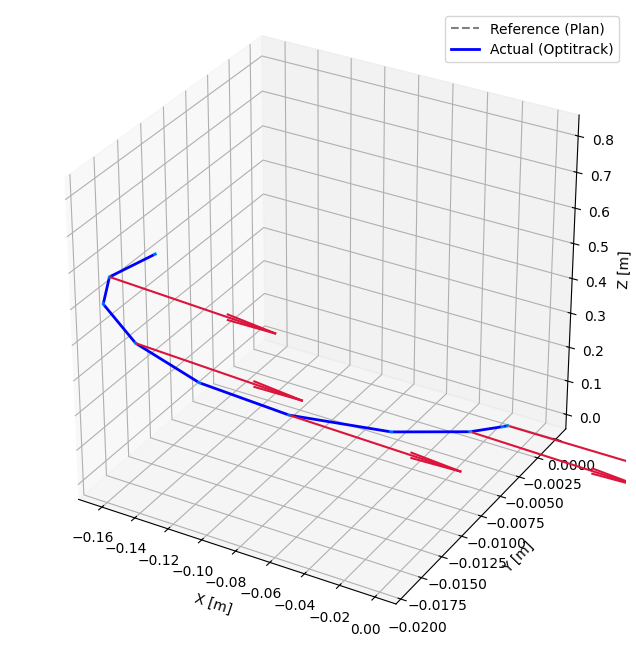

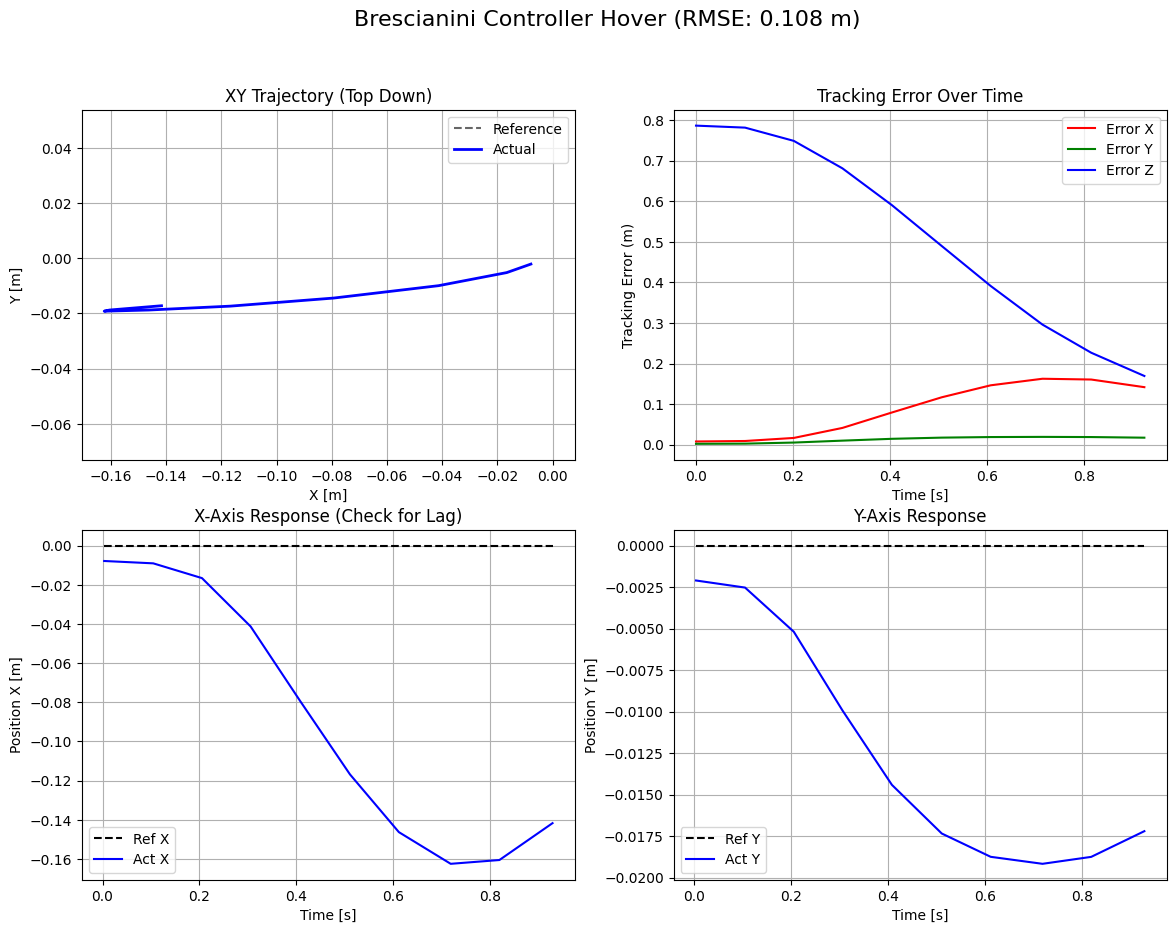

Total 3D RMSE:      0.5726 m
Max Tracking Error: 0.7862 m
Breakdown by Axis:
  X-Axis RMSE:      0.1075 m
  Y-Axis RMSE:      0.0142 m
  Z-Axis RMSE:      0.5622 m


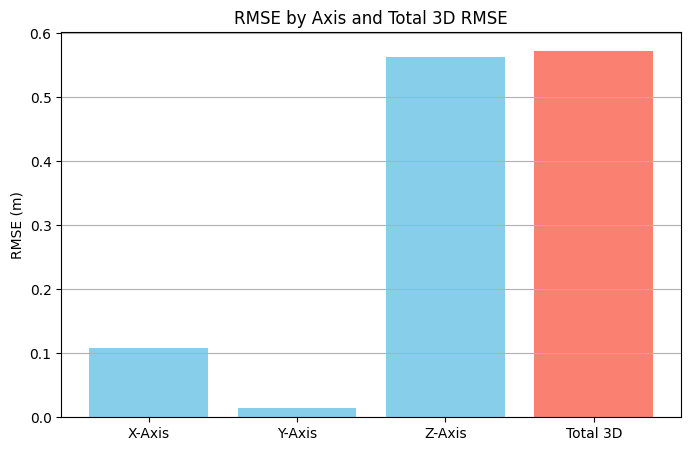

In [290]:

enhanced_visualise_planned_path_3D(bres_hover) # type: ignore
dashboard(bres_hover, "Brescianini Controller Hover")
rmse(bres_hover)

#### **Straight Line**

In [ ]:
bres_line = load_data(4,1)
bres_line.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act,err_x,err_y,err_z,error_3d
0,0.003397,-0.007856,-0.001630,0.014020,0,0,0.8,0.235317,-0.332839,0.004084,4,-0.007841,-0.002101,0.013806,0.007841,0.002101,0.786194,0.786236
1,0.104589,-0.007748,-0.001963,0.013937,0,0,0.8,0.321248,-0.220593,-0.206000,4,-0.009043,-0.002528,0.018721,0.009043,0.002528,0.781279,0.781336
2,0.205126,-0.008735,-0.002650,0.019287,0,0,0.8,1.302577,3.444424,-0.205914,4,-0.016585,-0.005189,0.051362,0.016585,0.005189,0.748638,0.748840
3,0.305487,-0.017634,-0.005760,0.053519,0,0,0.8,1.625639,9.237038,-0.268212,4,-0.041263,-0.009928,0.119043,0.041263,0.009928,0.680957,0.682278
4,0.407525,-0.044164,-0.010857,0.123048,0,0,0.8,-0.029713,7.353396,-0.212929,4,-0.079271,-0.014416,0.209722,0.079271,0.014416,0.590278,0.595751


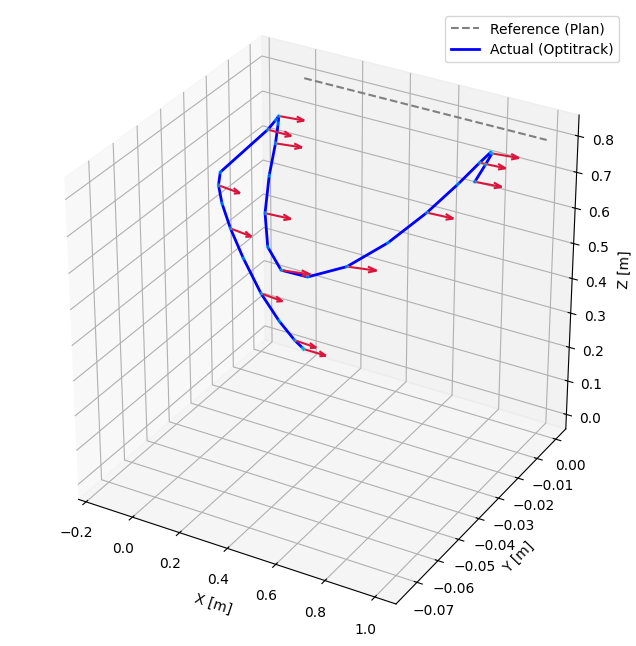

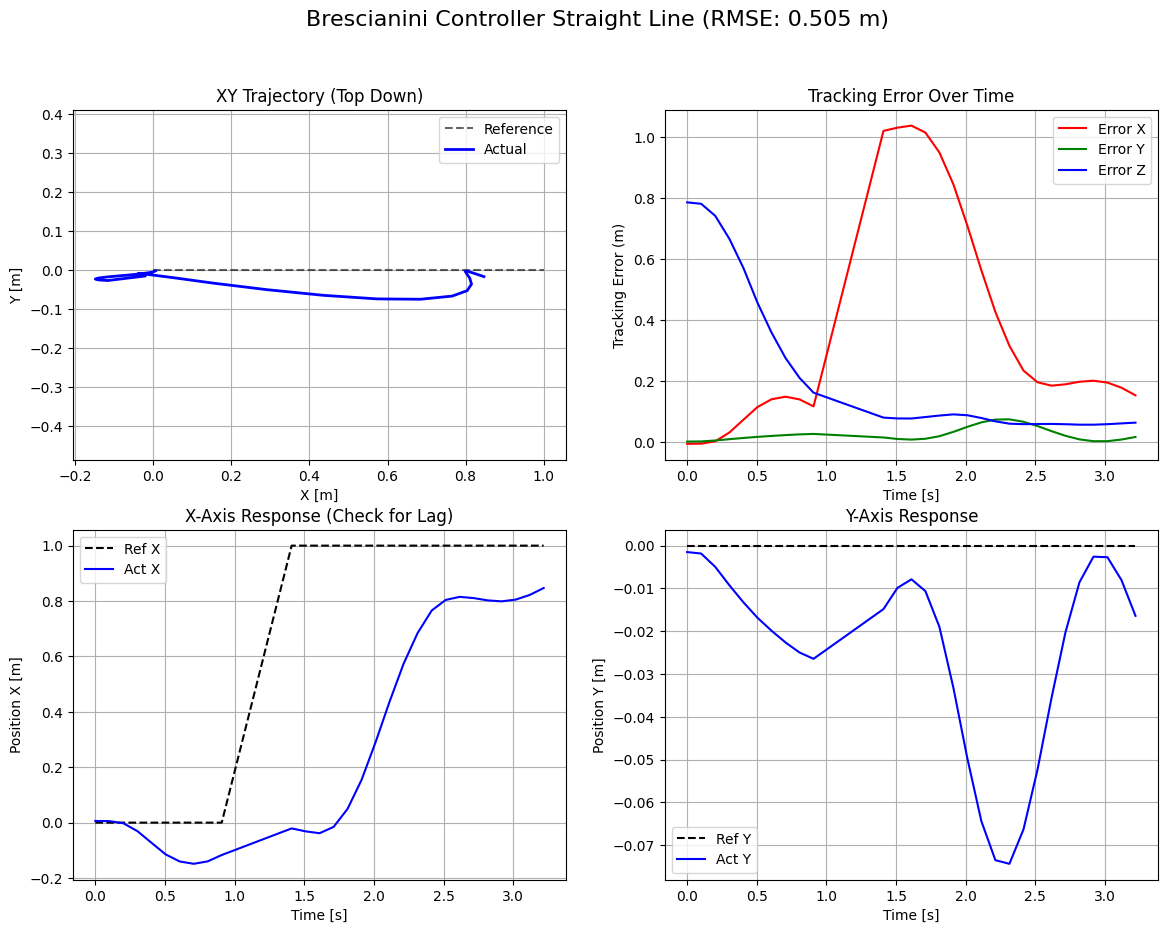

Total 3D RMSE:      0.6025 m
Max Tracking Error: 1.0410 m
Breakdown by Axis:
  X-Axis RMSE:      0.5039 m
  Y-Axis RMSE:      0.0330 m
  Z-Axis RMSE:      0.3285 m


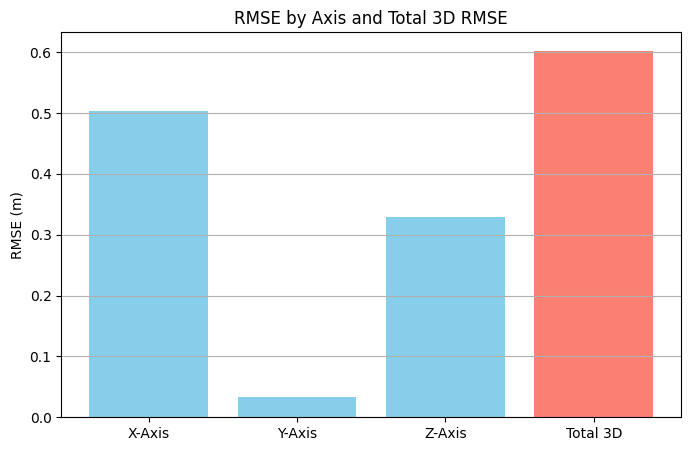

In [291]:
enhanced_visualise_planned_path_3D(bres_line) # type: ignore
dashboard(bres_line, "Brescianini Controller Straight Line")
rmse(bres_line)

#### **Sine Wave**

In [257]:
bres_sine = load_data(4,2)
bres_sine.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.001528,0.002004,-0.003347,0.013558,0.0,0.0,0.8,0.131933,-0.436180,0.014252,4,0.002174,-0.003411,0.013644
1,0.101910,0.002242,-0.003363,0.014933,0.0,0.0,0.8,0.929428,0.571268,0.051029,4,0.001489,-0.003488,0.018131
2,0.202379,-0.002974,-0.006070,0.041173,0.0,0.0,0.8,5.007752,10.988596,-0.283754,4,-0.008192,-0.007541,0.056597
3,0.302744,-0.029962,-0.014858,0.104437,0.0,0.0,0.8,1.044082,11.279653,-0.300466,4,-0.041469,-0.015620,0.129110
4,0.403347,-0.076200,-0.022775,0.193840,0.0,0.0,0.8,-1.429979,-0.173189,-0.631684,4,-0.088794,-0.022392,0.224256


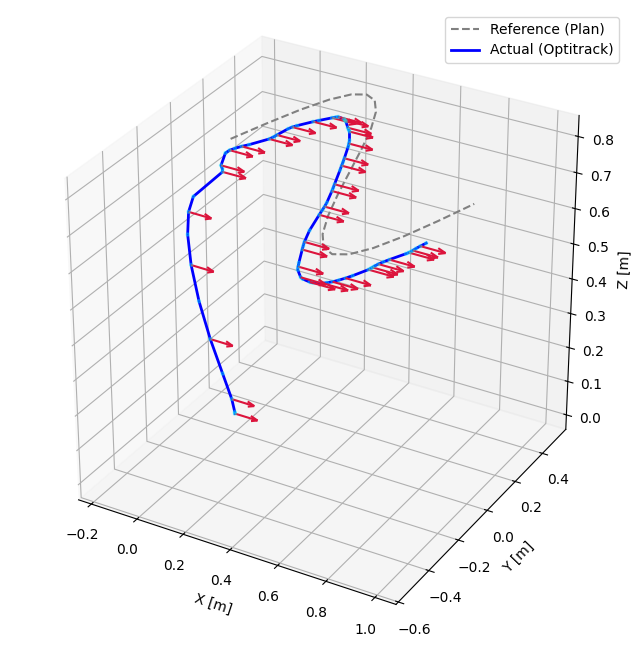

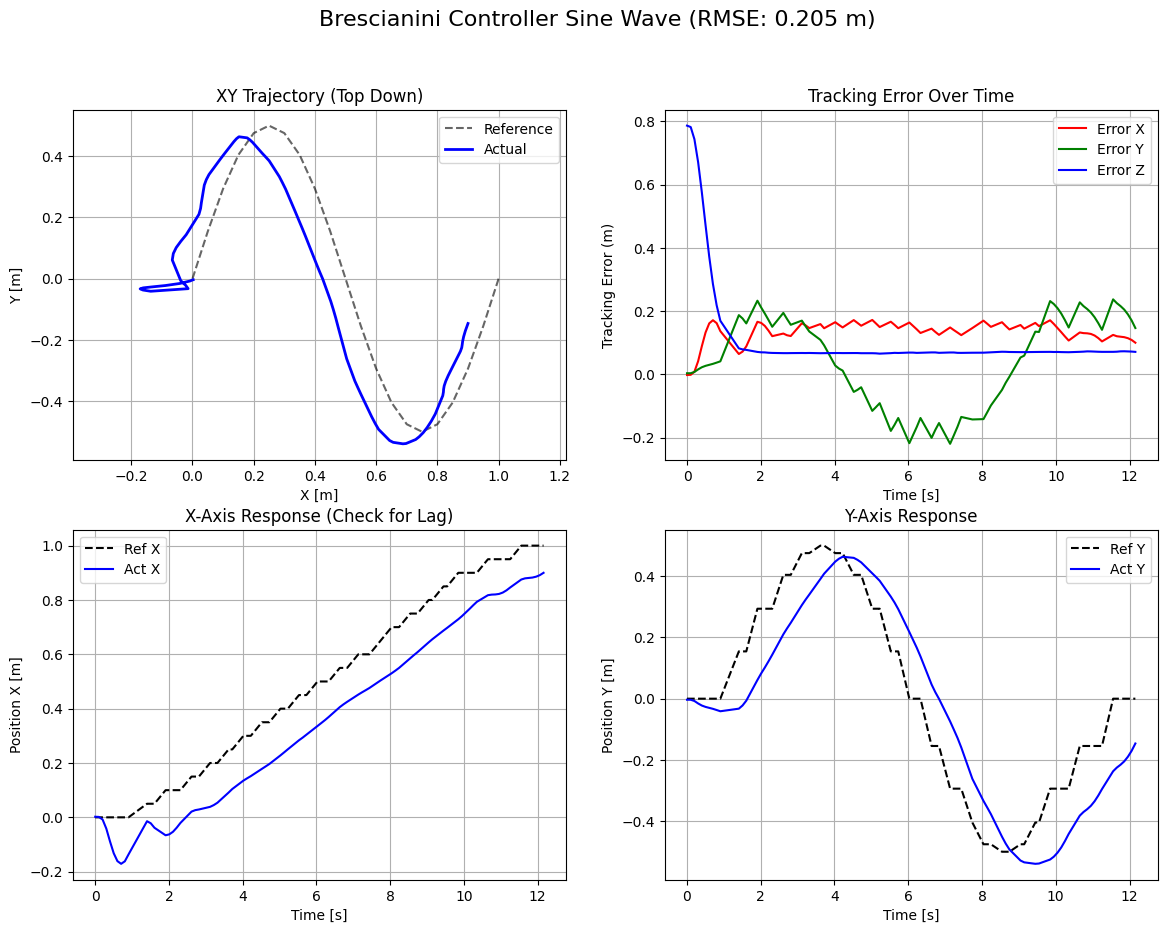

Total 3D RMSE:      0.2910 m
Max Tracking Error: 0.7864 m
Breakdown by Axis:
  X-Axis RMSE:      0.1380 m
  Y-Axis RMSE:      0.1512 m
  Z-Axis RMSE:      0.2069 m


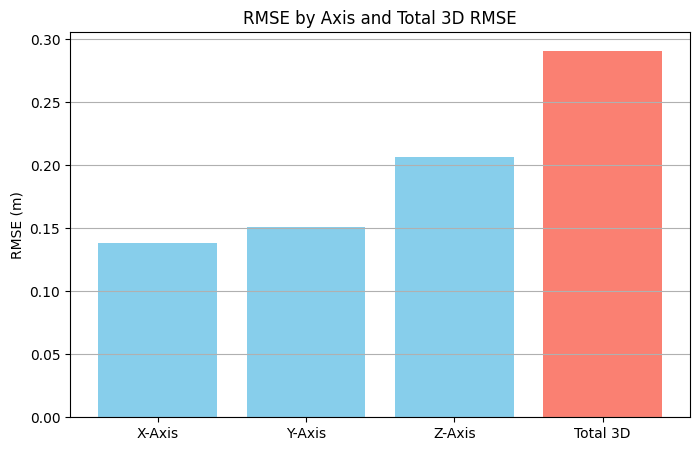

In [292]:
enhanced_visualise_planned_path_3D(bres_sine) # type: ignore
dashboard(bres_sine, "Brescianini Controller Sine Wave")
rmse(bres_sine)

#### **Figure 8**

In [ ]:
bres_figure8 = load_data(5,3)
bres_figure8.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.001217,0.004565,-0.001913,0.013683,0.0,0.0,0.8,0.175703,-0.404857,0.003006,4,0.004609,-0.002042,0.013693
1,0.101626,0.004538,-0.002212,0.015226,0.0,0.0,0.8,0.962866,1.118010,-0.347459,4,0.003604,-0.002605,0.017478
2,0.201918,-0.000514,-0.004948,0.035793,0.0,0.0,0.8,2.407095,10.251134,-0.444939,4,-0.004422,-0.006984,0.047450
3,0.302221,-0.024124,-0.013106,0.090176,0.0,0.0,0.8,2.011547,10.925442,-0.335631,4,-0.033032,-0.017244,0.112362
4,0.402767,-0.070110,-0.028079,0.182393,0.0,0.0,0.8,0.363033,1.688942,-0.084922,4,-0.077219,-0.031545,0.201393


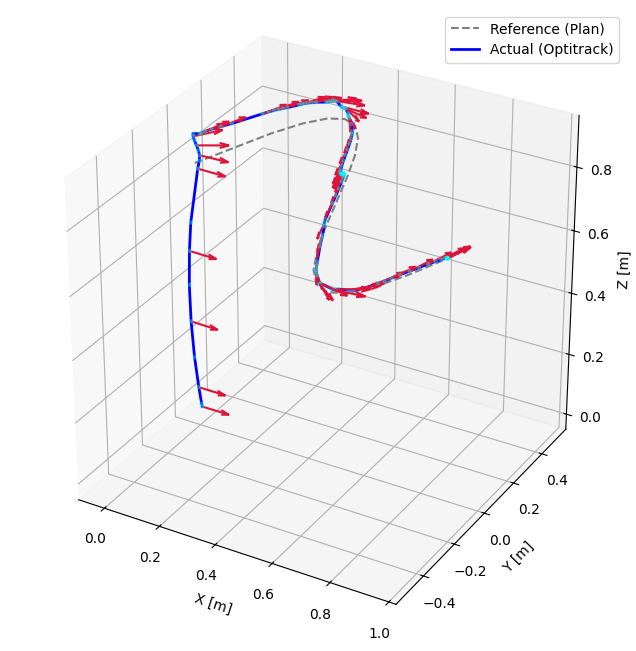

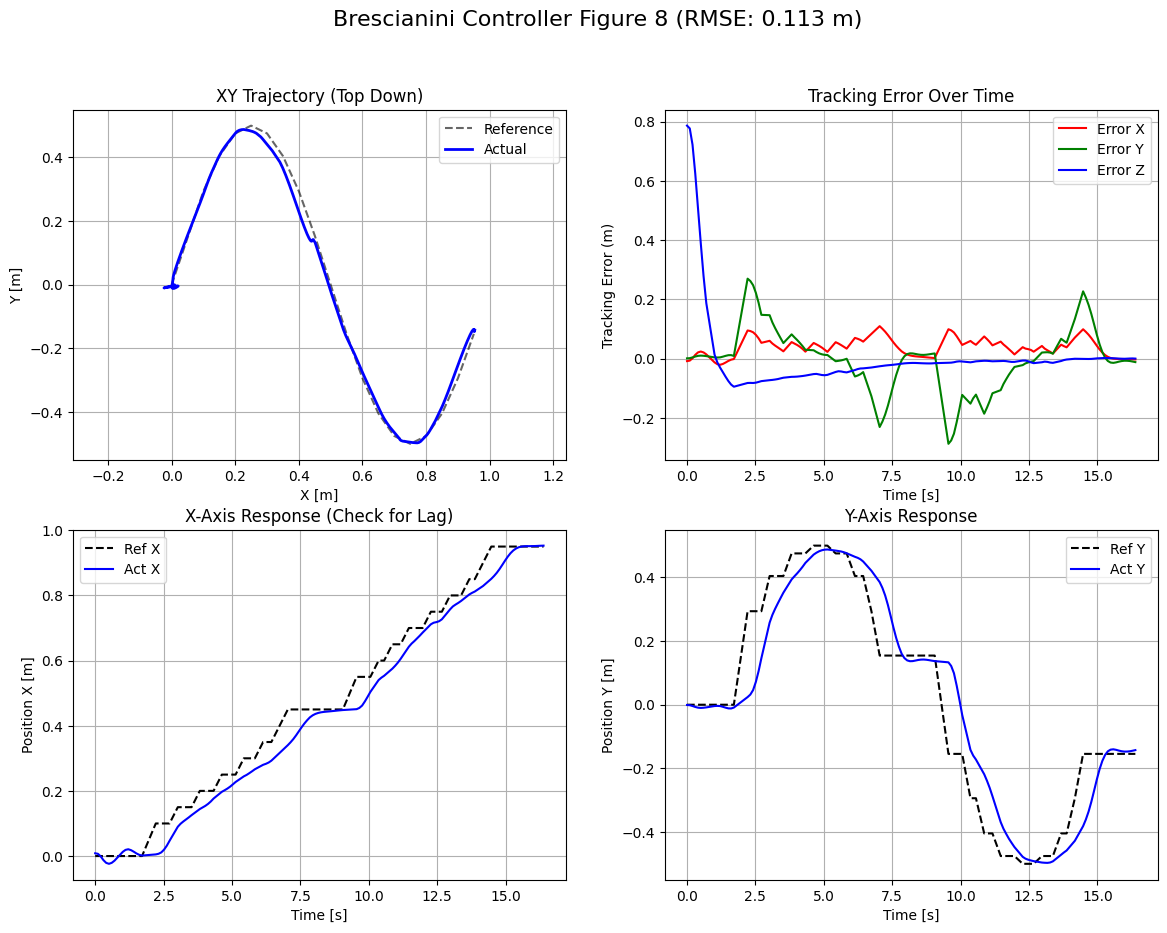

Total 3D RMSE:      0.1887 m
Max Tracking Error: 0.7866 m
Breakdown by Axis:
  X-Axis RMSE:      0.0479 m
  Y-Axis RMSE:      0.1029 m
  Z-Axis RMSE:      0.1507 m


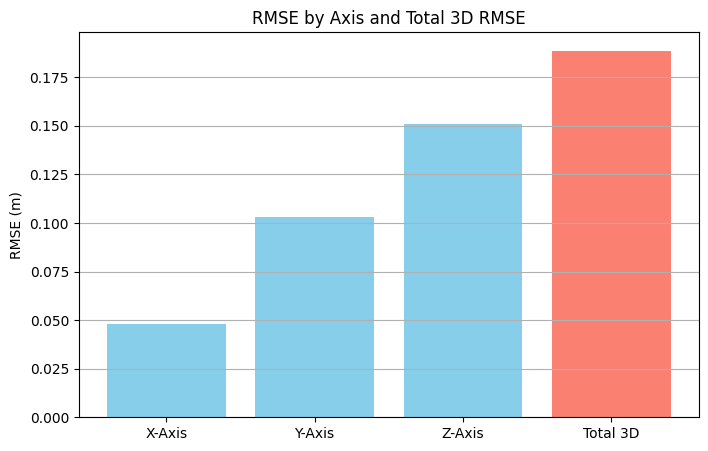

In [293]:
enhanced_visualise_planned_path_3D(bres_figure8) # type: ignore
dashboard(bres_figure8, "Brescianini Controller Figure 8")
rmse(bres_figure8)

## Lee

#### **Hover**

In [267]:
lee_hover = load_data(5,0)
lee_hover.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.001420,0.011274,0.007044,0.013500,0,0,0.8,0.409309,-0.305853,0.026859,5,0.011258,0.006866,0.013564
1,0.101747,0.011076,0.006193,0.018608,0,0,0.8,1.619281,2.209512,-0.480206,5,0.010310,0.005623,0.024120
2,0.202454,0.005176,0.001939,0.063690,0,0,0.8,1.314936,3.717494,-2.472874,5,0.003881,0.000738,0.079818
3,0.302972,-0.005855,-0.005312,0.154384,0,0,0.8,-0.864062,-0.579167,-2.483723,5,-0.006683,-0.006672,0.175059
4,0.404071,-0.014027,-0.010802,0.256870,0,0,0.8,-2.050658,-2.565880,-1.913096,5,-0.014917,-0.011449,0.287818


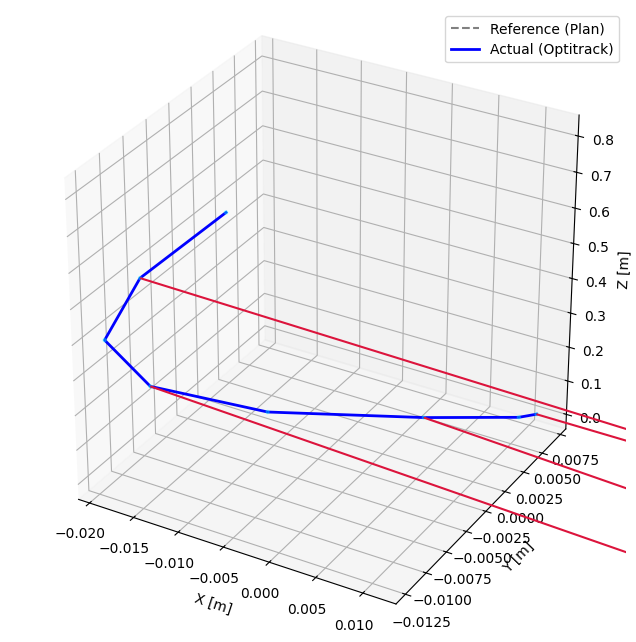

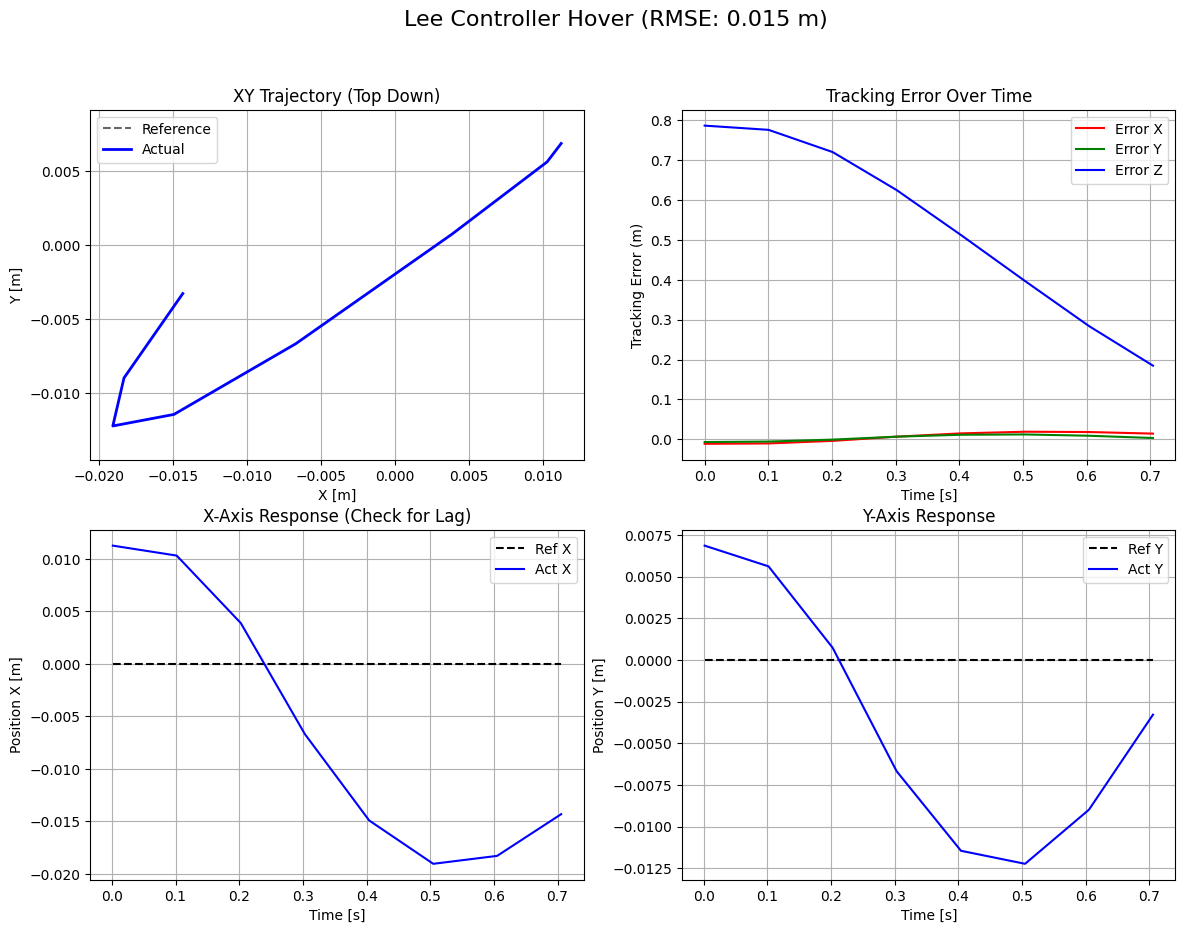

Total 3D RMSE:      0.5773 m
Max Tracking Error: 0.7865 m
Breakdown by Axis:
  X-Axis RMSE:      0.0133 m
  Y-Axis RMSE:      0.0079 m
  Z-Axis RMSE:      0.5771 m


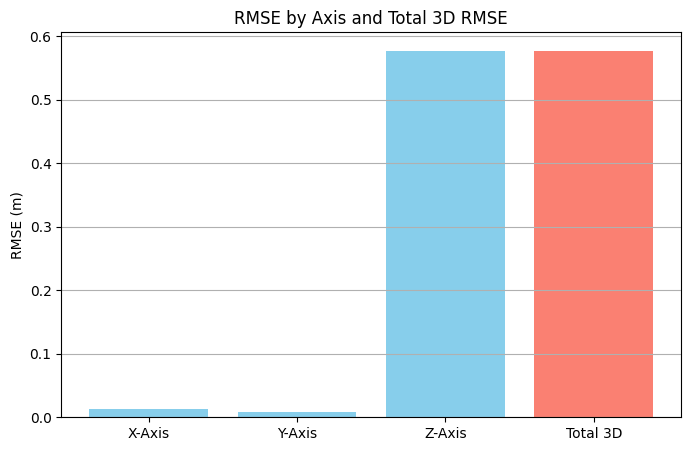

In [294]:
enhanced_visualise_planned_path_3D(lee_hover) # type: ignore
dashboard(lee_hover, "Lee Controller Hover")
rmse(lee_hover)

#### **Straight Line**

In [271]:
lee_line = load_data(5,1)
lee_line.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.000439,0.001838,0.003340,0.013465,0.0,0,0.8,0.134071,-0.567300,0.016723,5,0.002071,0.003172,0.013518
1,0.101209,0.002139,0.003018,0.016561,0.0,0,0.8,1.638070,1.420627,-0.610729,5,0.001211,0.002437,0.022016
2,0.201728,-0.003495,-0.000605,0.053662,0.0,0,0.8,2.469278,5.239277,-2.340017,5,-0.006598,-0.001906,0.073371
3,0.303123,-0.017436,-0.007231,0.137403,0.0,0,0.8,-1.018869,-0.886460,-2.153279,5,-0.022002,-0.008912,0.177761
4,0.403482,-0.029295,-0.012102,0.245702,0.0,0,0.8,-2.131134,-3.520075,-1.597275,5,-0.031969,-0.013507,0.292825


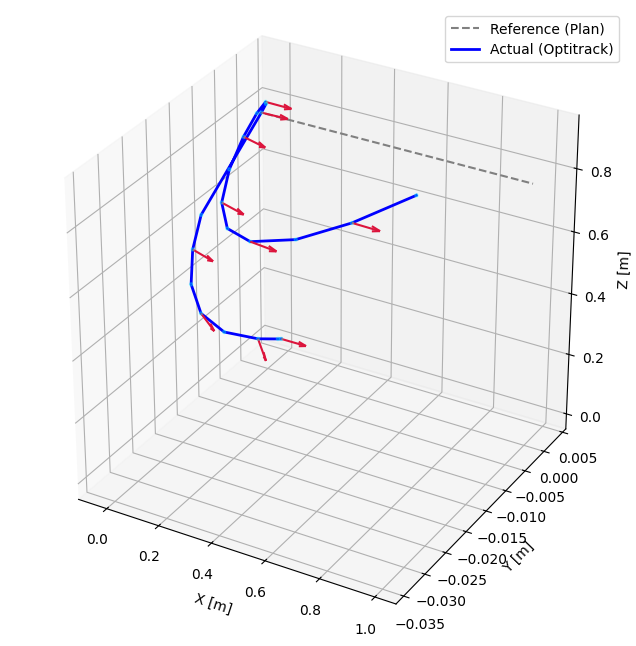

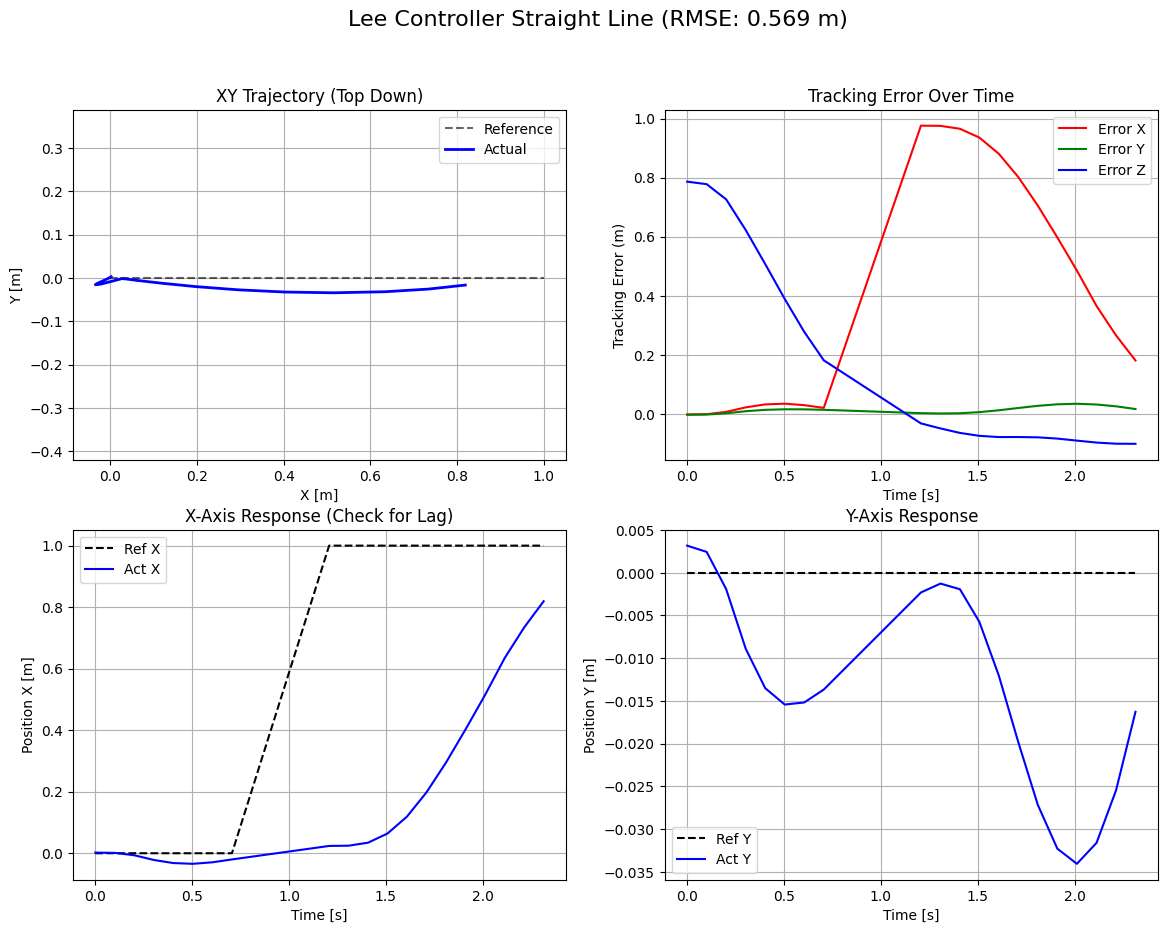

Total 3D RMSE:      0.6784 m
Max Tracking Error: 0.9768 m
Breakdown by Axis:
  X-Axis RMSE:      0.5684 m
  Y-Axis RMSE:      0.0178 m
  Z-Axis RMSE:      0.3698 m


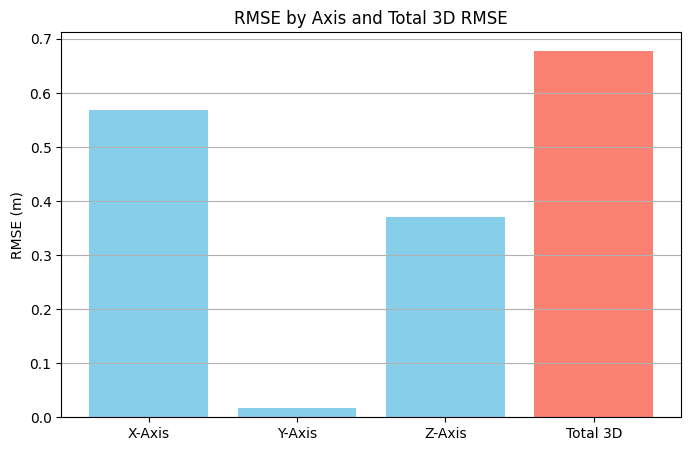

In [295]:
enhanced_visualise_planned_path_3D(lee_line) # type: ignore
dashboard(lee_line, "Lee Controller Straight Line")
rmse(lee_line)

#### **Sine Wave**

In [276]:
lee_sine = load_data(5,2)
lee_sine.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.001025,0.008303,-0.000696,0.013302,0.0,0.0,0.8,0.083937,-0.351269,0.024886,5,0.008463,-0.000864,0.013409
1,0.101702,0.008078,-0.001037,0.016537,0.0,0.0,0.8,0.902870,1.794749,-0.053381,5,0.006794,-0.001467,0.022848
2,0.202052,0.002421,-0.002936,0.053209,0.0,0.0,0.8,0.700660,3.640398,-0.896051,5,-0.001009,-0.004030,0.077607
3,0.302351,-0.009958,-0.006386,0.143423,0.0,0.0,0.8,-0.599083,-1.011458,-1.614040,5,-0.012615,-0.006976,0.175638
4,0.402807,-0.019032,-0.008642,0.249116,0.0,0.0,0.8,-0.915898,-2.728560,-1.768769,5,-0.020963,-0.009249,0.292941


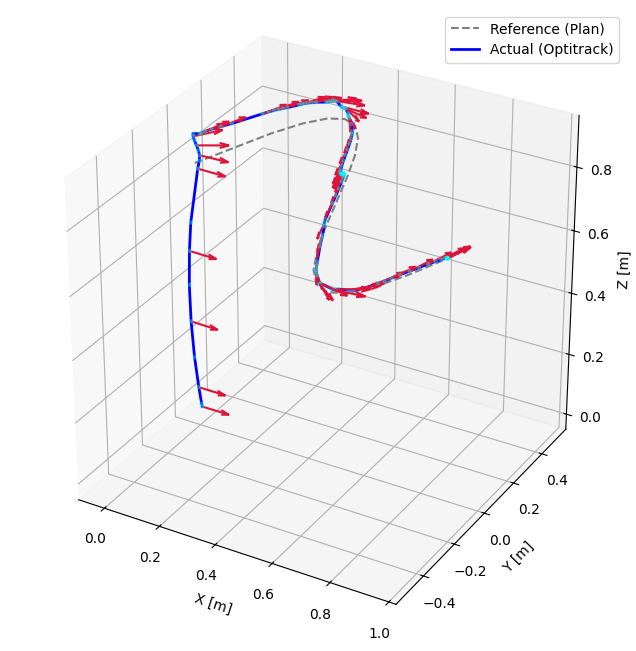

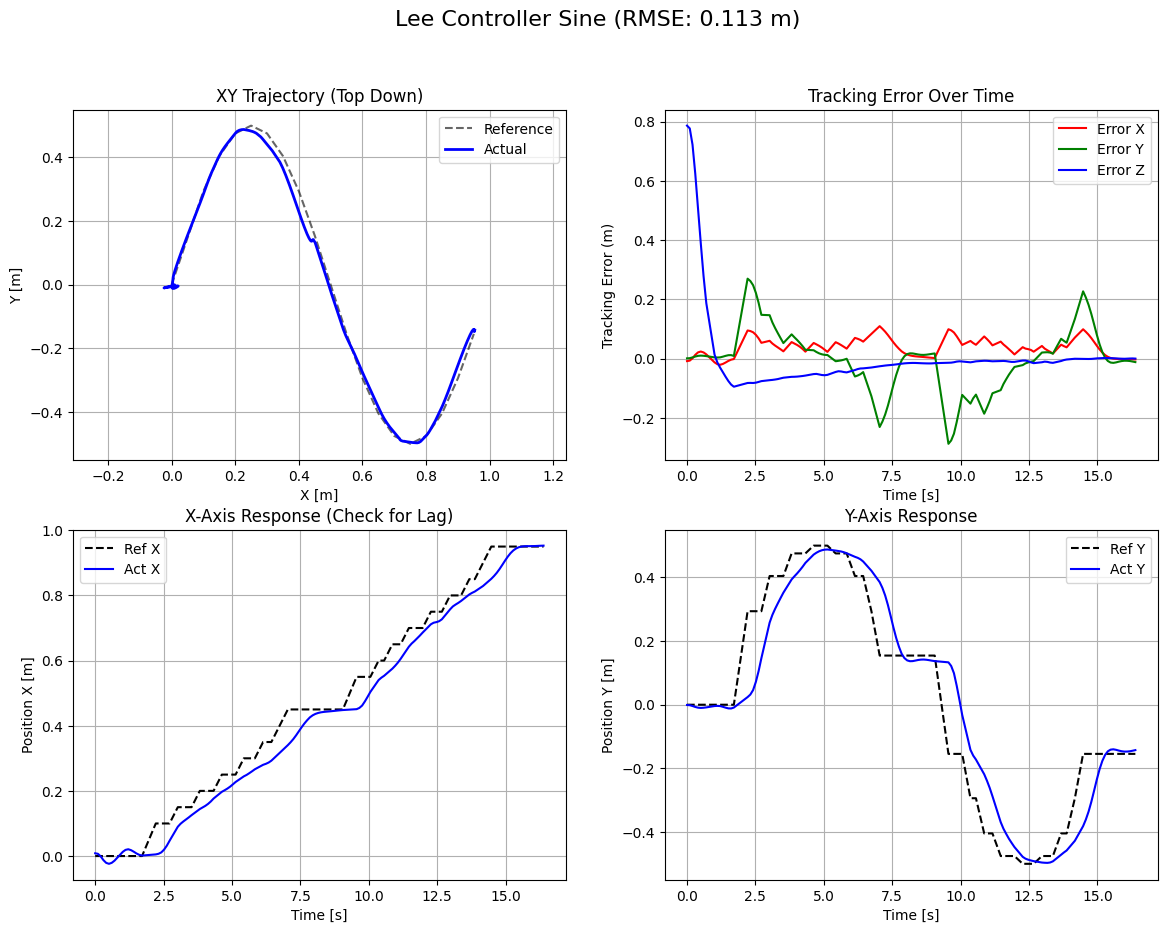

Total 3D RMSE:      0.1887 m
Max Tracking Error: 0.7866 m
Breakdown by Axis:
  X-Axis RMSE:      0.0479 m
  Y-Axis RMSE:      0.1029 m
  Z-Axis RMSE:      0.1507 m


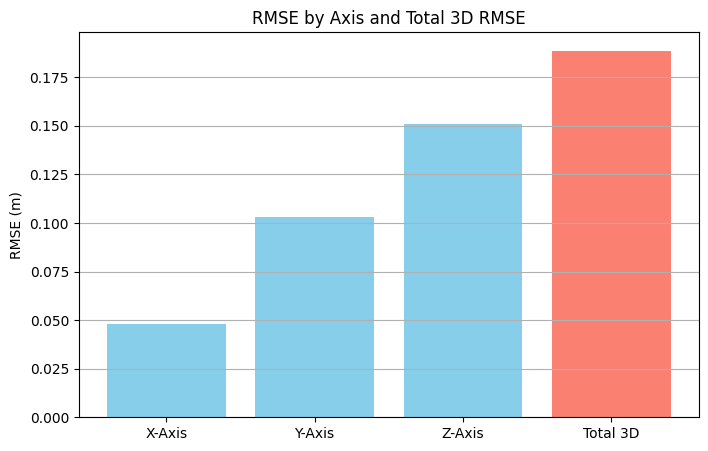

In [296]:
enhanced_visualise_planned_path_3D(lee_sine) # type: ignore
dashboard(lee_sine, "Lee Controller Sine")
rmse(lee_sine)

#### **Figure 8**

In [280]:
lee_figure8 = load_data(5,3)
lee_figure8.head(5)

,timestamp,x,y,z,target_x,target_y,target_z,roll,pitch,yaw,controller,x_act,y_act,z_act
0,0.000367,0.001887,0.000707,0.013306,0.0,0.0,0.8,0.027257,-0.445856,0.053078,5,0.001958,0.000476,0.013336
1,0.100932,0.002321,0.000684,0.017193,0.0,0.0,0.8,0.215503,1.275355,0.123642,5,0.002125,0.000478,0.020594
2,0.201672,-0.001349,-0.000714,0.058150,0.0,0.0,0.8,0.793257,4.839792,-0.730364,5,-0.001991,-0.001185,0.070989
3,0.302466,-0.011547,-0.003351,0.144751,0.0,0.0,0.8,-0.400272,-0.662887,-1.366721,5,-0.011614,-0.003672,0.158819
4,0.402767,-0.018621,-0.004905,0.232910,0.0,0.0,0.8,-0.913145,-1.994889,-1.644560,5,-0.020213,-0.005154,0.275195


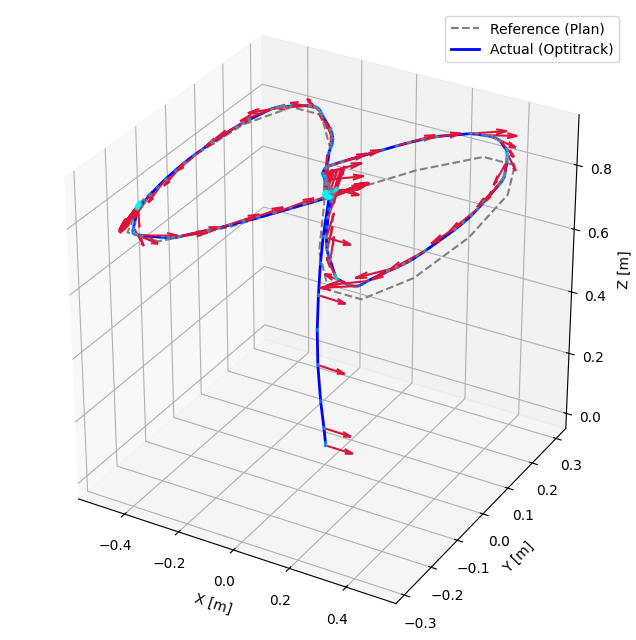

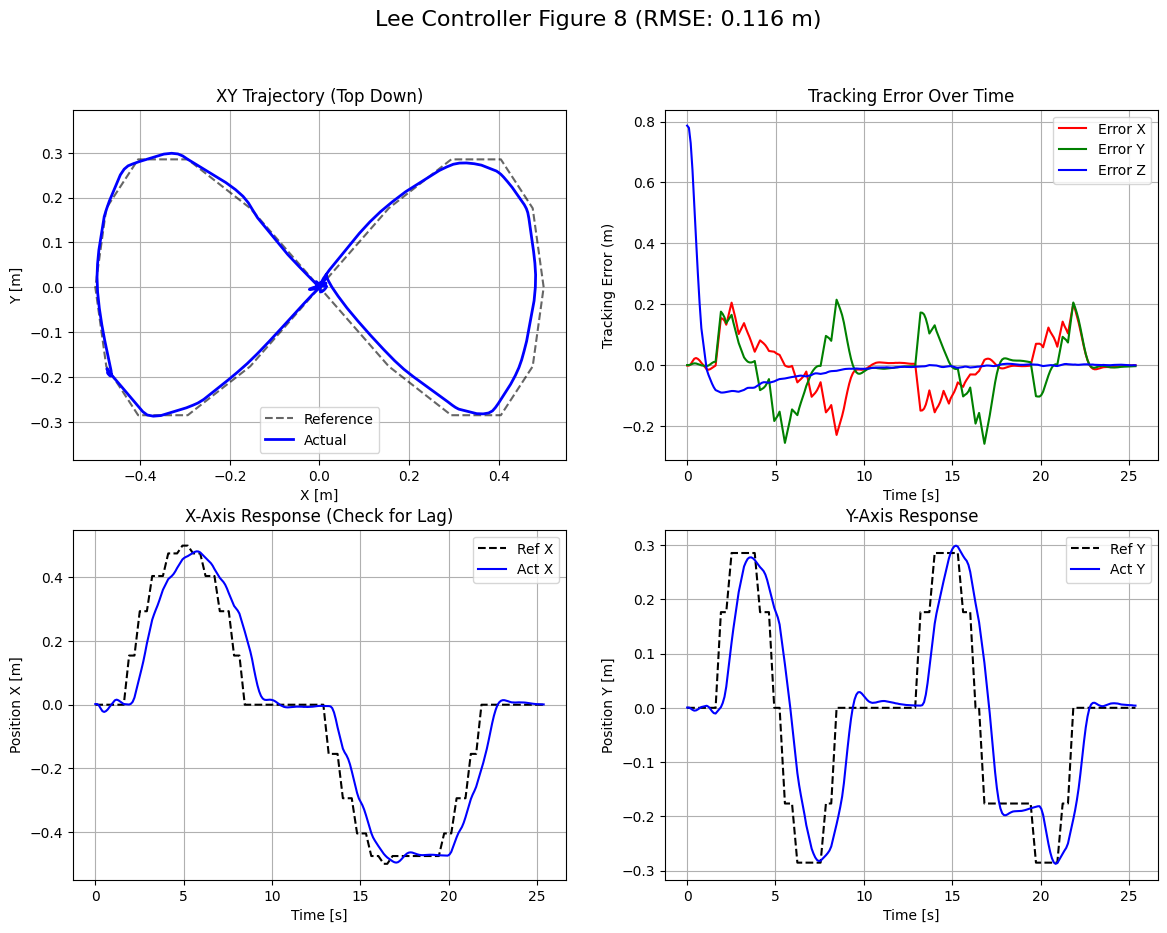

Total 3D RMSE:      0.1659 m
Max Tracking Error: 0.7867 m
Breakdown by Axis:
  X-Axis RMSE:      0.0760 m
  Y-Axis RMSE:      0.0879 m
  Z-Axis RMSE:      0.1184 m


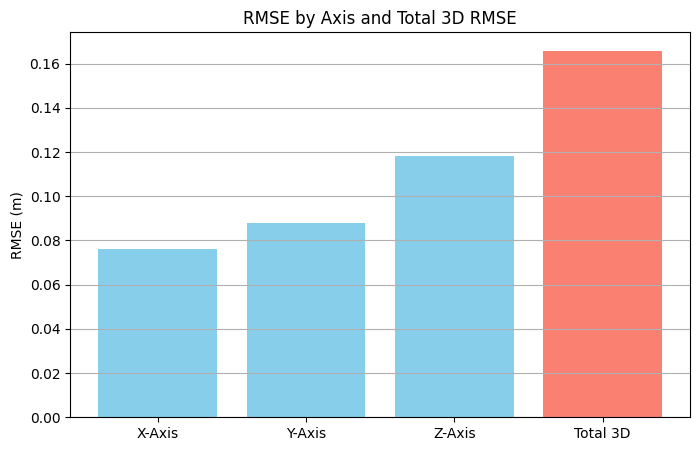

In [297]:


enhanced_visualise_planned_path_3D(lee_figure8) # type: ignore
dashboard(lee_figure8, "Lee Controller Figure 8")
rmse(lee_figure8)

## Conclusions

Overall best performance in my opinion showed Lee controller since this controller showed the highest precision overall during 4 flights.

| Controller    | Hover (RMSE) | Straight Line (RMSE) | Sine Wave (RMSE) | Figure-8 (RMSE) |
|--------------|--------------|----------------------|------------------|-----------------|
| PID          | 0.041 m      | 0.553 m              | 0.115 m          | 0.131 m         |
| Mellinger   | 0.021 m      | 0.587 m              | 0.173 m          | 0.246 m         |
| INDI         | 0.021 m      | 0.481 m              | 0.147 m          | 0.219 m         |
| Brescianini | 0.108 m      | 0.505 m              | 0.205 m          | 0.116 m         |
| Lee          | 0.015 m      | 0.569 m              | 0.113 m          | 0.116 m         |
